# N04 - Application: Eliminating a Lossy Bosonic Mediator
## Coherent interactions, collective decay, reconstruction, physicality, and the memory boundary

A rapidly relaxing bosonic mode can mediate coherent interactions and dissipative
channels among slower degrees of freedom. Eliminating it therefore produces a
**complete open-system theory**, not a Hamiltonian with a complex denominator
inserted by hand:

$$
\boxed{\text{effective open dynamics}
=
\text{coherent terms}
+
\text{dissipative terms}
+
\text{encoding and reconstruction}.}
$$

The principal benchmark is a lossy cavity coupled to two qubits. The notebook
compares the full cavity master equation, a Hamiltonian-only reduction, and the
complete effective master equation, and then asks when the mediator must be
retained rather than eliminated.

## 1. Two reading paths

**Manuscript-support path.** Sections 3--13 derive and validate the statements used
directly in the application: the complex susceptibility, effective Hamiltonian and
jump, several transition frequencies, bright/dark collective states, full versus
effective dynamics, mediator reconstruction, physicality, and the first closing-gap
failure.

**Independent-learning path.** Sections 14--19 go further. They study slow-pole
scaling, a genuine bosonic cutoff stress test, nonvacuum mediator references,
nonlinear reservoir engineering, conditional versus Liouvillian exceptional points,
and a saturable lossy-qubit auxiliary.

The two paths share one rule: the reduced object must be chosen according to the
physical claim. A Hamiltonian can be sufficient for a coherent spectral question,
while an unconditional open-system claim generally requires a master equation or
finite-time map.

## 2. Learning goals and claim-diagnostic map

After completing the notebook, the reader should be able to:

1. identify the fast Liouvillian or non-Hermitian sector;
2. derive coherent and dissipative slow terms from the same inverse fast response;
3. relate effective-operator, Langevin, projection, and dissipative
   Schrieffer--Wolff descriptions;
4. resolve several nondegenerate slow transition frequencies;
5. distinguish conditional no-jump dynamics from the unconditional master equation;
6. reconstruct the leading mediator occupation and its initial layer;
7. test Kossakowski and finite-time Choi positivity;
8. separate physicality from quantitative accuracy;
9. perform a genuine bosonic cutoff test beyond a one-excitation sector;
10. recognize the closing-gap regime in which the mediator must remain explicit.

| Claim | Minimum comparison | Diagnostic | First repair |
|---|---|---|---|
| mediated coherent exchange | full vs effective Hamiltonian | transition frequencies / transfer | include coherent higher-order corrections |
| unconditional reduced dynamics | full GKLS vs complete effective GKLS | trace distance, purity, concurrence | restore effective jump |
| eliminated-mode observable | full mediator vs reconstructed observable | mediator occupation and initial layer | reconstruct or retain mediator |
| several Bohr frequencies | full model vs frequency-resolved reduction | state error and Kossakowski spectrum | partial/secular block treatment |
| complete positivity | generator or finite-time map | Kossakowski / Choi eigenvalues | repair the dissipative block |
| near closing fast gap | full model vs time-local reduced generator | slow pole, memory, mediator occupation | enlarge retained space / memory kernel |

## 3. Manuscript schematic

The following code generates the canonical four-panel schematic used for the article application.
It summarizes the microscopic model, the coherent/dissipative split of one complex
response, encoding and reconstruction, and the validity/memory boundary.

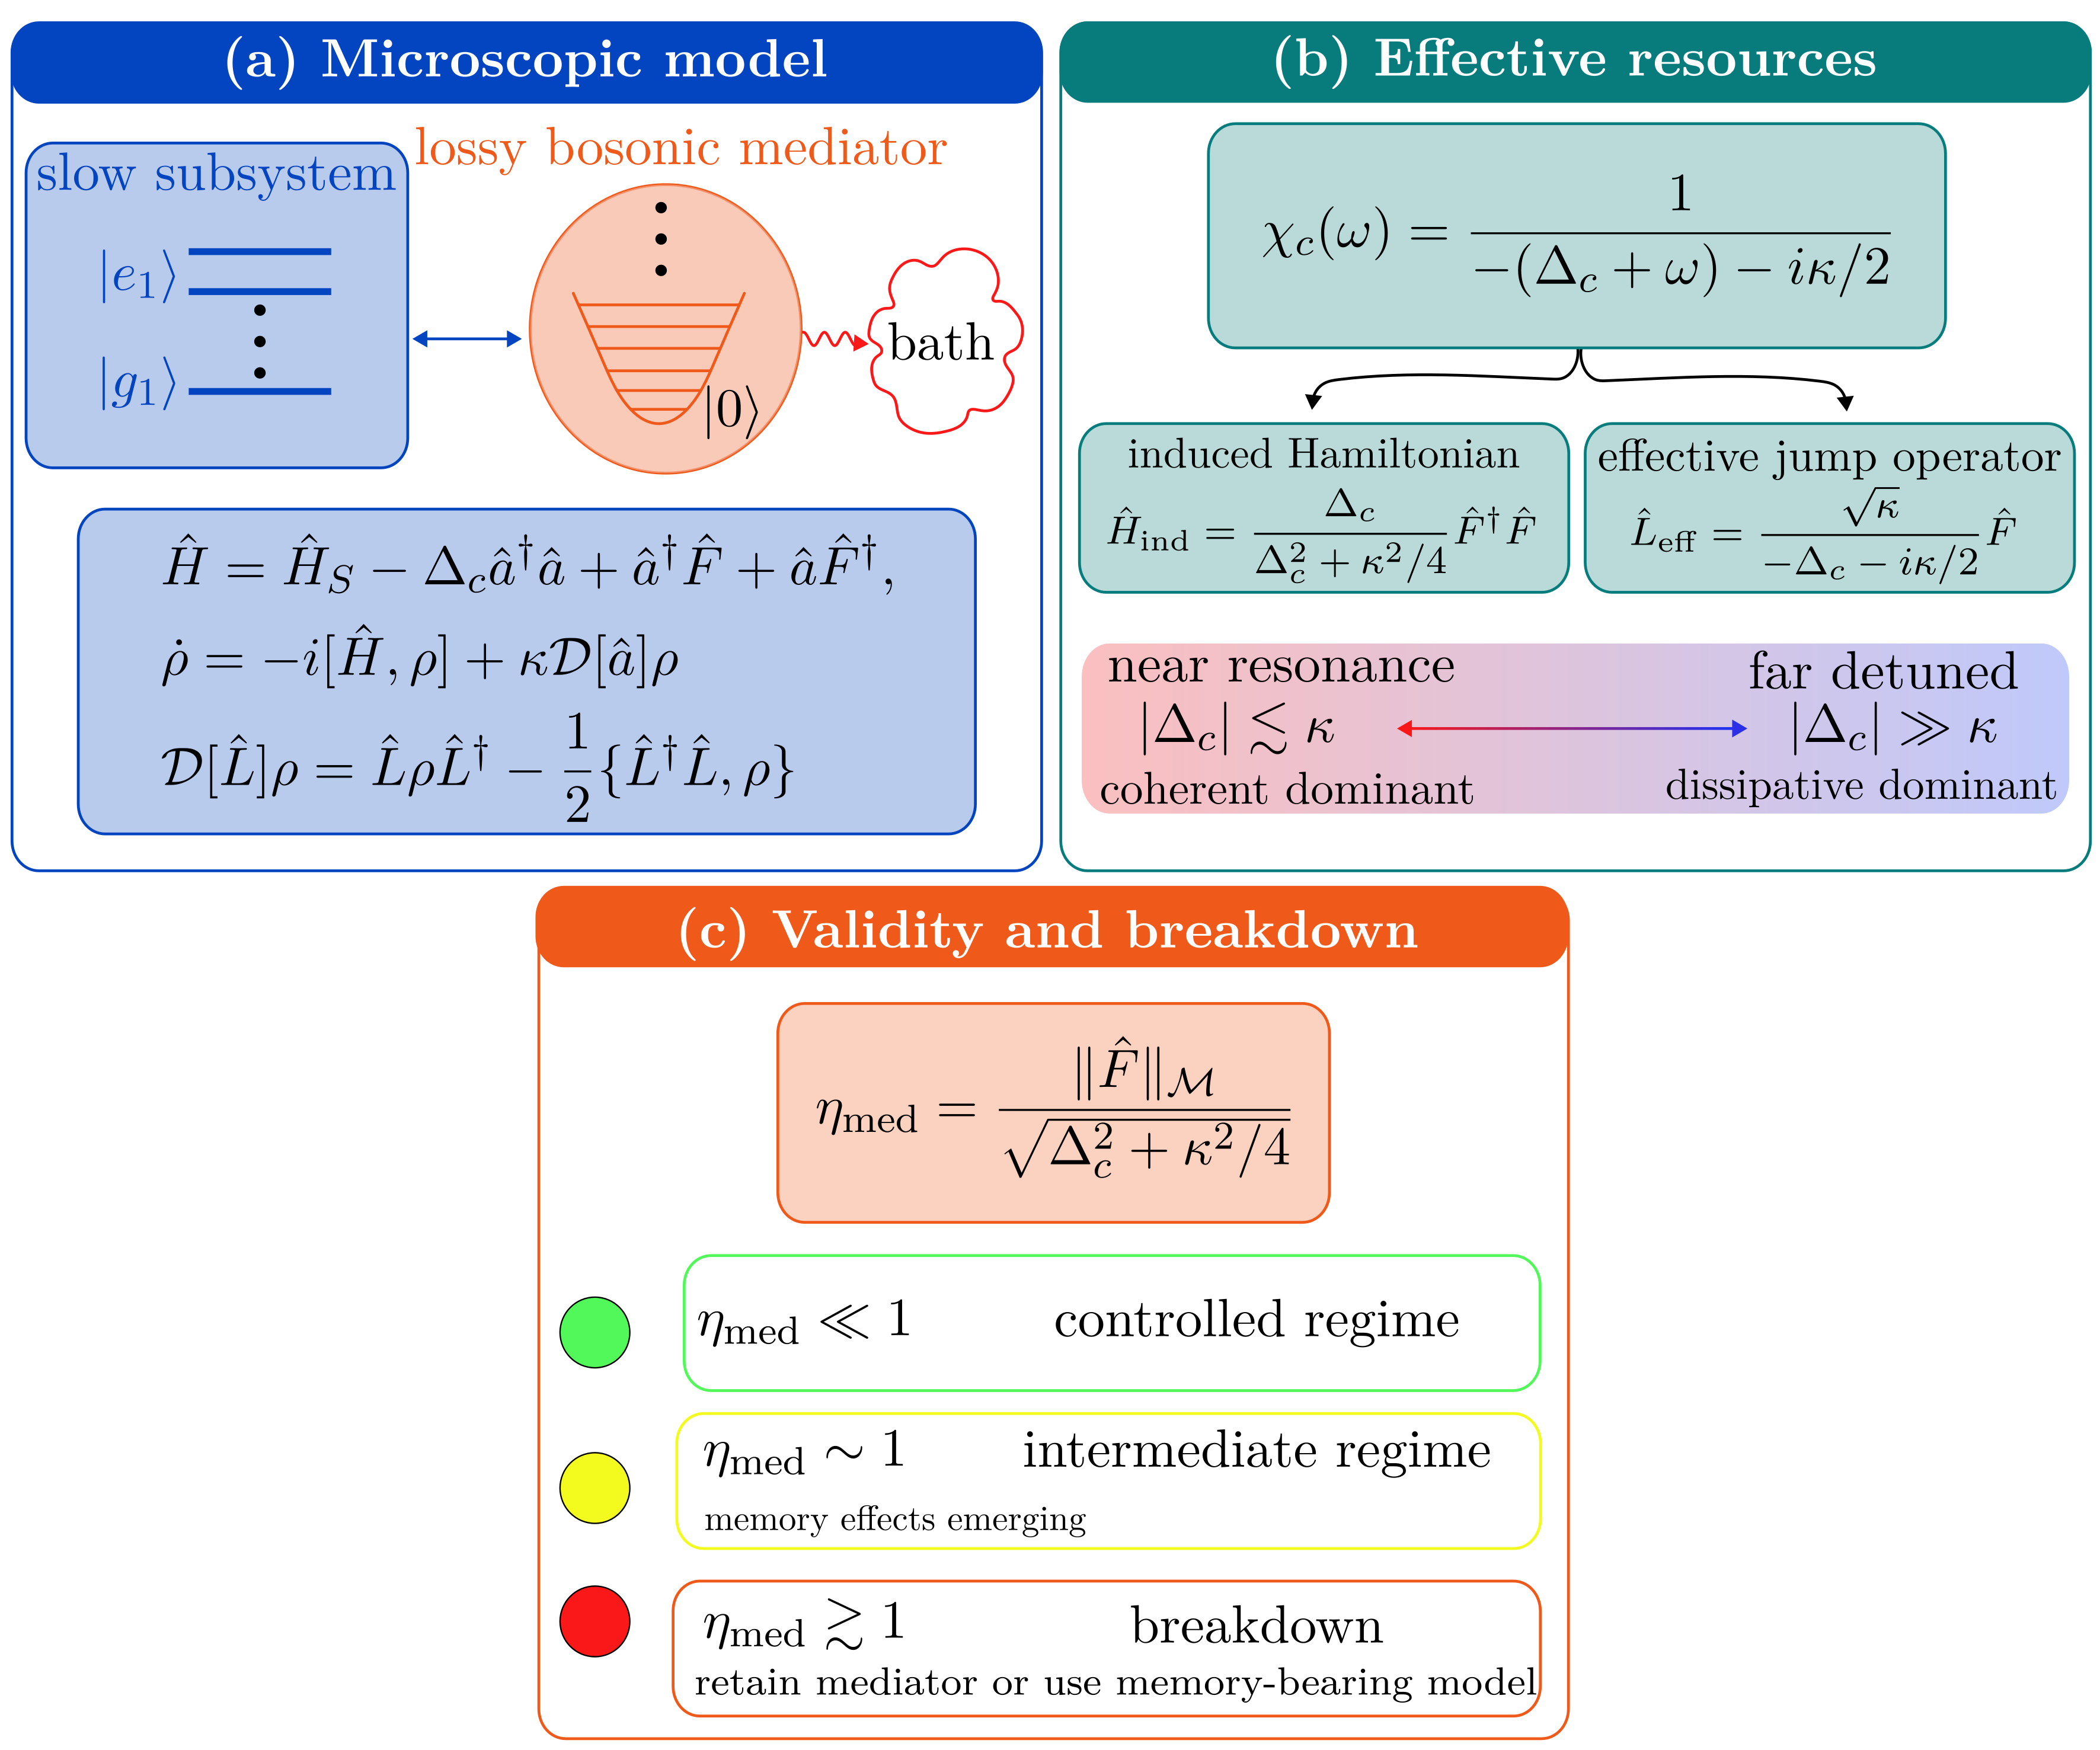

In [1]:
from hashlib import sha256
import shutil
from pathlib import Path
from IPython.display import Image, display

asset_pdf = Path("assets/manuscript/N04_MF1.pdf")
asset_png = Path("assets/manuscript/N04_MF1.png")
target_dir = Path("figures/manuscript")
target_dir.mkdir(parents=True, exist_ok=True)
target_pdf = target_dir / "N04_MF1.pdf"
target_png = target_dir / "N04_MF1.png"
shutil.copy2(asset_pdf, target_pdf)
shutil.copy2(asset_png, target_png)
assert sha256(asset_pdf.read_bytes()).hexdigest() == "8dda2a97fce65118485f1bb91501dce8c79d59bbc76a380bf4af59b6e8518f27"
assert sha256(target_pdf.read_bytes()).hexdigest() == "8dda2a97fce65118485f1bb91501dce8c79d59bbc76a380bf4af59b6e8518f27"
display(Image(filename=str(target_png), width=920))

**Manuscript Figure N04_MF1. Eliminating a lossy bosonic mediator.**
A fast damped mode is coupled to a slow subsystem through $F$. The same complex
susceptibility generates an induced Hamiltonian and an effective jump. The reference
fast state belongs to the encoding map, and observables involving the eliminated
mode require reconstruction. When the complex fast gap closes, the mediator must be
retained or replaced by a memory-bearing description.

## 4. Microscopic model and dissipator convention

We use
$$
H=H_S-\Delta_c a^\dagger a+a^\dagger F+aF^\dagger ,
$$
with mediator damping
$$
\dot\rho=-i[H,\rho]+\kappa\,\mathcal D[a]\rho,
\qquad
\mathcal D[L]\rho
=
L\rho L^\dagger-\frac12\{L^\dagger L,\rho\}.
$$

This is the standard QuTiP dissipator convention. It is equivalent to writing
$(\kappa/2)\mathcal D_2[a]$ with
$\mathcal D_2[L]\rho=2L\rho L^\dagger-\{L^\dagger L,\rho\}$.
In either notation the field amplitude decays at $\kappa/2$ and the photon number
at $\kappa$.

The default fast reference state is the mediator vacuum. A coherent reference should
first be displaced. Thermal and squeezed references have different correlation
matrices and generally generate additional upward/downward or phase-sensitive
channels; they are not obtained by changing only one denominator.

## 5. Operational derivation: one inverse fast block, two resources

For a vacuum reference define
$$
P=|0\rangle\langle0|\otimes I_S,\qquad Q=1-P,
$$
and
$$
V_+=a^\dagger F,\qquad V_-=aF^\dagger .
$$
In the one-fast-excitation sector,
$$
H_{\rm NH}
=
\left(-\Delta_c-i\frac{\kappa}{2}\right)|1\rangle\langle1|.
$$

The effective-operator construction gives
$$
H_{\rm ind}
=
-\frac12V_-
\left(H_{\rm NH}^{-1}+H_{\rm NH}^{-1\dagger}\right)V_+,
$$
$$
L_{\rm eff}
=
\sqrt{\kappa}\,aH_{\rm NH}^{-1}V_+.
$$
Therefore
$$
\boxed{
H_{\rm ind}
=
\frac{\Delta_c}{\Delta_c^2+\kappa^2/4}\,F^\dagger F,
}
$$
and
$$
\boxed{
L_{\rm eff}
=
\frac{\sqrt{\kappa}}{-\Delta_c-i\kappa/2}\,F.
}
$$

The induced Hamiltonian and the effective jump are the dispersive and absorptive
parts of the same eliminated propagation. Keeping the first while discarding the
second is not an order-consistent unconditional theory.

## 6. Langevin response, small rotations, James--Jerke, projection, and dissipative SW

The Heisenberg--Langevin equation is
$$
\dot a=
\left(i\Delta_c-\frac{\kappa}{2}\right)a-iF-\sqrt{\kappa}\,a_{\rm in}.
$$
For a Bohr component $F_\omega e^{-i\omega t}$,
$$
a_\omega\simeq-\chi_c(\omega)F_\omega,
\qquad
\chi_c(\omega)=
\frac{1}{-(\Delta_c+\omega)-i\kappa/2}.
$$

At one frequency,
$$
H_{\rm ind}=-\operatorname{Re}\chi_c\,F^\dagger F,
\qquad
L_{\rm eff}=\sqrt{\kappa}\,\chi_cF
$$
up to an irrelevant phase of the jump.

The same reduction can be organized in several useful ways:

| Route | What it exposes best | Important limitation |
|---|---|---|
| small unitary rotation | far-detuned coherent shift, dressing, virtual occupation | finite linewidth/noise still has to be carried through the transformed dissipator |
| James--Jerke averaging | second-order coherent beat and bounded micromotion | Hamiltonian averaging alone does not generate the recycling term |
| Langevin/input--output | susceptibility, input noise, transient, memory | most transparent for linear auxiliaries |
| effective operators | direct finite-linewidth $H_{\rm ind}$ and $L_{\rm eff}$ | assumes a controlled fast eliminated manifold |
| Liouvillian projection | reduced inverse and fast spectral gap | algebra can be less transparent |
| dissipative Schrieffer--Wolff | block diagonalization of the Liouvillian | same gap requirement remains |

At second order, Liouvillian projection has the structural form
$$
\mathcal L_{\rm eff}
=
P\mathcal LP
-
P\mathcal LQ\,
(Q\mathcal LQ)^{-1}\,
Q\mathcal LP
+\cdots .
$$
No increase in perturbative order can repair a fast block whose spectral gap has
actually closed.

## 7. QuTiP implementation

The physical benchmark uses QuTiP for operators, tensor products, GKLS evolution,
partial traces, concurrence, trace distance, Liouvillian spectra, finite-time maps,
and bosonic states. Dense NumPy arrays are used only for ordinary scalar tables and
small classical linear-algebra summaries.

In [2]:
from pathlib import Path
import json
import logging
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import scienceplots

import qutip as qt
from qutip import (
    Qobj,
    basis,
    coherent,
    concurrence,
    destroy,
    expect,
    ket2dm,
    liouvillian,
    mesolve,
    qeye,
    sigmam,
    sigmap,
    spre,
    spost,
    tensor,
    thermal_dm,
    to_choi,
    tracedist,
)


# Matplotlib/fontTools can emit harmless legacy-font timestamp messages while
# embedding STIX fonts.  They are unrelated to the quantum calculation.
logging.getLogger("fontTools.ttLib.tables._h_e_a_d").setLevel(logging.ERROR)

plt.style.use(["science", "notebook"])

# Figure typography and geometry matched to N08 / SciPost.
# All generated figures use a physical canvas width of exactly 150 mm.
FIG_WIDTH_150MM = 150.0 / 25.4
SCIPOST_FONT_SIZE = 10.95
DOT_STYLE = (0, (1.0, 2.2))

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "text.usetex": True,
    "font.family": "serif",
    "font.size": SCIPOST_FONT_SIZE,
    "axes.labelsize": SCIPOST_FONT_SIZE,
    "axes.titlesize": SCIPOST_FONT_SIZE,
    "legend.fontsize": SCIPOST_FONT_SIZE,
    "xtick.labelsize": SCIPOST_FONT_SIZE,
    "ytick.labelsize": SCIPOST_FONT_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.35,
    "lines.markersize": 4.2,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

ROOT = Path.cwd()
FIG_MANUSCRIPT = ROOT / "figures" / "manuscript"
FIG_NOTEBOOK = ROOT / "figures" / "notebook"
DATA_DIR = ROOT / "data"
for directory in (FIG_MANUSCRIPT, FIG_NOTEBOOK, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SOLVER = {
    "method": "bdf",
    "atol": 1e-10,
    "rtol": 1e-8,
    "nsteps": 30000,
    "store_states": True,
    "progress_bar": False,
}

def save_figure(fig, stem, manuscript=False):
    directory = FIG_MANUSCRIPT if manuscript else FIG_NOTEBOOK
    modified_stem = f"{stem}"
    # Preserve the 150 mm physical canvas.  bbox_inches="tight" would
    # recalculate the bounding box and therefore change the exported width.
    fig.savefig(directory / f"{modified_stem}.pdf", dpi=600)
    fig.savefig(directory / f"{modified_stem}.png", dpi=600)

def save_table(frame, stem):
    frame.to_csv(DATA_DIR / f"{stem}.csv", index=False)

def scalar(value):
    if isinstance(value, complex):
        return value
    if np.isscalar(value):
        return complex(value)
    return complex(np.asarray(value).reshape(-1)[0])


def as_two_qubit_dm(state):
    """Return a two-qubit density matrix with explicit tensor dimensions.

    QuTiP's unitary solver path can occasionally return a 4-component ket with
    flattened Hilbert-space metadata.  The amplitudes are correct, but routines
    such as qutip.concurrence intentionally require explicit [2, 2] subsystem
    dimensions.  Reattaching those dimensions is an observable-layer operation;
    it does not alter the state or the dynamics.
    """
    if state.isket:
        ket = Qobj(state.full().reshape((4, 1)), dims=[[2, 2], [1, 1]])
        return ket2dm(ket)
    if state.isbra:
        ket = Qobj(state.dag().full().reshape((4, 1)), dims=[[2, 2], [1, 1]])
        return ket2dm(ket)
    if state.shape == (4, 4):
        return Qobj(state.full(), dims=[[2, 2], [2, 2]])
    raise ValueError(
        f"Expected a two-qubit ket/bra/density matrix, got shape={state.shape}, dims={state.dims}"
    )

E = basis(2, 0)
G = basis(2, 1)
P_E = ket2dm(E)
P_G = ket2dm(G)

def build_two_qubit_mediator(
    cavity_dim=3,
    detuning=2.0,
    kappa=4.0,
    g1=0.25,
    g2=0.25,
    omega1=0.0,
    omega2=0.0,
):
    a = tensor(destroy(cavity_dim), qeye(2), qeye(2))
    sm1 = tensor(qeye(cavity_dim), sigmam(), qeye(2))
    sm2 = tensor(qeye(cavity_dim), qeye(2), sigmam())
    pe1 = tensor(qeye(cavity_dim), P_E, qeye(2))
    pe2 = tensor(qeye(cavity_dim), qeye(2), P_E)
    F = g1 * sm1 + g2 * sm2

    Hs = omega1 * pe1 + omega2 * pe2
    H = Hs - detuning * a.dag() * a + a.dag() * F + a * F.dag()
    c_ops = [np.sqrt(kappa) * a]

    sm1_s = tensor(sigmam(), qeye(2))
    sm2_s = tensor(qeye(2), sigmam())
    pe1_s = tensor(P_E, qeye(2))
    pe2_s = tensor(qeye(2), P_E)
    F_s = g1 * sm1_s + g2 * sm2_s
    Hs_s = omega1 * pe1_s + omega2 * pe2_s

    den = detuning**2 + (kappa / 2.0)**2
    H_ind = detuning / den * F_s.dag() * F_s
    L_eff = np.sqrt(kappa) / (-detuning - 0.5j * kappa) * F_s

    return {
        "H_full": H,
        "c_full": c_ops,
        "a": a,
        "F_full": F,
        "H_slow": Hs_s,
        "F_slow": F_s,
        "H_ind": H_ind,
        "H_eff": Hs_s + H_ind,
        "L_eff": L_eff,
        "receiver_full": tensor(qeye(cavity_dim), qeye(2), P_E),
        "receiver_slow": tensor(qeye(2), P_E),
        "sender_slow": tensor(P_E, qeye(2)),
        "denominator": den,
        "susceptibility_0": 1.0 / (-detuning - 0.5j * kappa),
    }

def full_initial_state(cavity_dim):
    return tensor(basis(cavity_dim, 0), E, G)

psi_slow_eg = tensor(E, G)
psi_slow_ee = tensor(E, E)
ground_slow = tensor(G, G)

DELTA = 2.0
KAPPA = 4.0
G1 = 0.25
G2 = 0.25
NC = 3
TMAX = 120.0
TIMES = np.linspace(0.0, TMAX, 301)

## 8. Exact benchmark: full cavity, complete effective ME, and Hamiltonian-only truncation

For two degenerate qubits,
$$
F=g_1\sigma_-^{(1)}+g_2\sigma_-^{(2)}.
$$
The manuscript benchmark uses
$$
\Delta_c=2,\qquad
\kappa=4,\qquad
g_1=g_2=0.25,
$$
mediator vacuum, and initial qubit state $|eg\rangle$.

All three models below use the same parameters. The Hamiltonian-only approximation
keeps $H_{\rm ind}$ but drops $L_{\rm eff}$; it is deliberately incomplete.

### State representation used for observables

The full and dissipative effective branches naturally return density matrices.
The Hamiltonian-only branch is unitary and may be returned by QuTiP as a ket. Before
evaluating concurrence, purity, or state distance, the notebook converts every
two-qubit state to a density matrix with explicit tensor dimensions
$[[2,2],[2,2]]$. This changes only the representation supplied to the observable
routine, not the physical state or its evolution.


In [3]:
baseline = build_two_qubit_mediator(
    cavity_dim=NC,
    detuning=DELTA,
    kappa=KAPPA,
    g1=G1,
    g2=G2,
)

out_full = mesolve(
    baseline["H_full"],
    full_initial_state(NC),
    TIMES,
    c_ops=baseline["c_full"],
    options=SOLVER,
)
out_eff = mesolve(
    baseline["H_eff"],
    psi_slow_eg,
    TIMES,
    c_ops=[baseline["L_eff"]],
    options=SOLVER,
)
out_ham = mesolve(
    baseline["H_eff"],
    psi_slow_eg,
    TIMES,
    c_ops=[],
    options=SOLVER,
)

rho_full_slow = [
    as_two_qubit_dm(state.ptrace([1, 2]))
    for state in out_full.states
]
rho_eff_slow = [
    as_two_qubit_dm(state)
    for state in out_eff.states
]
rho_ham_slow = [
    as_two_qubit_dm(state)
    for state in out_ham.states
]

receiver_full = np.asarray(
    expect(baseline["receiver_full"], out_full.states), dtype=float
)
receiver_eff = np.asarray(
    expect(baseline["receiver_slow"], rho_eff_slow), dtype=float
)
receiver_ham = np.asarray(
    expect(baseline["receiver_slow"], rho_ham_slow), dtype=float
)

concurrence_full = np.array([concurrence(rho) for rho in rho_full_slow])
concurrence_eff = np.array([concurrence(rho) for rho in rho_eff_slow])
concurrence_ham = np.array([concurrence(rho) for rho in rho_ham_slow])

trace_eff = np.array([
    tracedist(rho, sigma)
    for rho, sigma in zip(rho_full_slow, rho_eff_slow)
])
trace_ham = np.array([
    tracedist(rho, sigma)
    for rho, sigma in zip(rho_full_slow, rho_ham_slow)
])

purity_full = np.array([rho.purity() for rho in rho_full_slow])
purity_eff = np.array([rho.purity() for rho in rho_eff_slow])
purity_ham = np.array([rho.purity() for rho in rho_ham_slow])

cavity_full = np.asarray(
    expect(baseline["a"].dag() * baseline["a"], out_full.states),
    dtype=float,
)

baseline_summary = pd.DataFrame({
    "quantity": [
        "local_mixing_eta",
        "max_trace_distance_complete",
        "max_trace_distance_hamiltonian_only",
        "long_time_concurrence_full",
        "max_mediator_population",
    ],
    "value": [
        np.sqrt(G1**2 + G2**2) / np.sqrt(baseline["denominator"]),
        trace_eff.max(),
        trace_ham.max(),
        concurrence_full[-1],
        cavity_full.max(),
    ],
})
save_table(baseline_summary, "N04_D1")
baseline_summary

,quantity,value
0,local_mixing_eta,0.125000
1,max_trace_distance_complete,0.009366
2,max_trace_distance_hamiltonian_only,0.797663
3,long_time_concurrence_full,0.499916
4,max_mediator_population,0.008425


The complete reduction should follow the full reduced state closely. The
Hamiltonian-only model can reproduce an exchange scale while predicting the wrong
purity, collective decay, and entanglement because the bright component has no
effective decay channel.

## 9. Bright and dark collective states

For $g_1=g_2=g$,
$$
|B\rangle=\frac{|eg\rangle+|ge\rangle}{\sqrt2},
\qquad
|D\rangle=\frac{|eg\rangle-|ge\rangle}{\sqrt2}.
$$
The collective jump is proportional to
$\sigma_-^{(1)}+\sigma_-^{(2)}$, hence
$$
L_{\rm eff}|D\rangle=0.
$$

Since
$$
|eg\rangle=\frac{|B\rangle+|D\rangle}{\sqrt2},
$$
the bright half decays and the ideal dark half survives. The asymptotic incoherent
mixture
$$
\frac12|D\rangle\langle D|+\frac12|gg\rangle\langle gg|
$$
has concurrence $1/2$. Coupling asymmetry, local decay, dephasing, and additional
frequency sectors break this ideal protection.

In [4]:
B = (tensor(E, G) + tensor(G, E)).unit()
D = (tensor(E, G) - tensor(G, E)).unit()

bright_dark_checks = pd.DataFrame({
    "quantity": [
        "norm_L_eff_on_dark",
        "norm_L_eff_on_bright",
        "ideal_dark_mixture_concurrence",
    ],
    "value": [
        (baseline["L_eff"] * D).norm(),
        (baseline["L_eff"] * B).norm(),
        concurrence(
            0.5 * ket2dm(D) + 0.5 * ket2dm(tensor(G, G))
        ),
    ],
})
save_table(bright_dark_checks, "N04_D2")
bright_dark_checks

,quantity,value
0,norm_L_eff_on_dark,0.00
1,norm_L_eff_on_bright,0.25
2,ideal_dark_mixture_concurrence,0.50


## 10. Reconstructing the eliminated mediator and its initial layer

For a slowly varying source,
$$
a_{\rm sl}(t)\simeq
\frac{F(t)}{\Delta_c+i\kappa/2}.
$$
A bare vacuum preparation is generally not on this instantaneous slow manifold.
Enforcing $a(0)=0$ gives the leading initial-layer reconstruction
$$
a_{\rm rec}(t)\simeq
a_{\rm sl}(t)
-
e^{(i\Delta_c-\kappa/2)t}\,a_{\rm sl}(0).
$$

For the one-excitation benchmark, the no-jump slow amplitude is sufficient to
evaluate the complete amplitude-level reconstruction, including the interference
between the instantaneous slow response and the homogeneous transient. In a general
mixed or driven problem the analogous expression is a two-time correlation
calculation rather than a product of instantaneous occupations.

In [5]:
H_nh_eff = (
    baseline["H_eff"]
    - 0.5j * baseline["L_eff"].dag() * baseline["L_eff"]
)
source0 = scalar(
    ground_slow.dag() * baseline["F_slow"] * psi_slow_eg
)
den_amp = DELTA + 0.5j * KAPPA

slaved_population = []
initial_layer_population = []

for time in TIMES:
    psi_nj = (-1j * H_nh_eff * time).expm() * psi_slow_eg
    source_t = scalar(
        ground_slow.dag() * baseline["F_slow"] * psi_nj
    )
    a_sl = source_t / den_amp
    a_rec = a_sl - np.exp((1j * DELTA - KAPPA / 2.0) * time) * (source0 / den_amp)
    slaved_population.append(abs(a_sl)**2)
    initial_layer_population.append(abs(a_rec)**2)

slaved_population = np.asarray(slaved_population)
initial_layer_population = np.asarray(initial_layer_population)

reconstruction_summary = pd.DataFrame({
    "quantity": [
        "max_abs_error_slaved",
        "max_abs_error_initial_layer",
        "improvement_factor",
    ],
    "value": [
        np.max(np.abs(cavity_full - slaved_population)),
        np.max(np.abs(cavity_full - initial_layer_population)),
        np.max(np.abs(cavity_full - slaved_population))
        / max(np.max(np.abs(cavity_full - initial_layer_population)), 1e-15),
    ],
})
save_table(reconstruction_summary, "N04_D3")

baseline_dynamics = pd.DataFrame({
    "t": TIMES,
    "receiver_full": receiver_full,
    "receiver_complete": receiver_eff,
    "receiver_hamiltonian_only": receiver_ham,
    "concurrence_full": concurrence_full,
    "concurrence_complete": concurrence_eff,
    "concurrence_hamiltonian_only": concurrence_ham,
    "trace_distance_complete": trace_eff,
    "trace_distance_hamiltonian_only": trace_ham,
    "purity_full": purity_full,
    "purity_complete": purity_eff,
    "purity_hamiltonian_only": purity_ham,
    "mediator_population_full": cavity_full,
    "mediator_population_slaved": slaved_population,
    "mediator_population_initial_layer": initial_layer_population,
})
save_table(baseline_dynamics, "N04_D4")

reconstruction_summary

,quantity,value
0,max_abs_error_slaved,0.007813
1,max_abs_error_initial_layer,0.000092
2,improvement_factor,85.194128


## 11. Manuscript quantitative validation

The primary manuscript benchmark separates four claims: mediated transfer,
bright/dark entanglement, reduced-state accuracy, and reconstruction of the eliminated
mode.

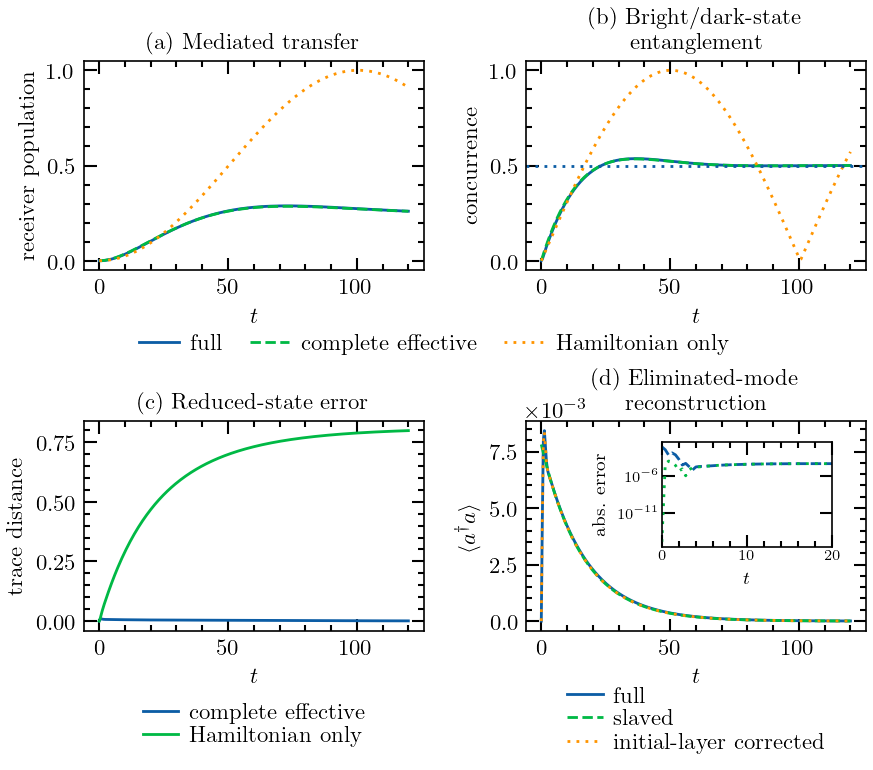

In [6]:
fig = plt.figure(figsize=(FIG_WIDTH_150MM, 5.8))
gs = fig.add_gridspec(
    2, 2,
    left=0.105, right=0.988,
    bottom=0.145, top=0.8,
    hspace=0.72, wspace=0.30,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

legend_kw = dict(
    frameon=False,
    handlelength=1.70,
    handletextpad=0.50,
    labelspacing=0.18,
    borderaxespad=0.28,
)

# ============================================================
# (a)
# ============================================================
ax = axes[0, 0]
l1, = ax.plot(TIMES, receiver_full, label="full")
l2, = ax.plot(TIMES, receiver_eff, "--", label="complete effective")
l3, = ax.plot(TIMES, receiver_ham, linestyle=DOT_STYLE, label="Hamiltonian only")
ax.set(
    xlabel=r"$t$",
    ylabel="receiver population",
    title="(a) Mediated transfer",
)

# ============================================================
# (b)
# ============================================================
ax = axes[0, 1]
ax.plot(TIMES, concurrence_full, label="full")
ax.plot(TIMES, concurrence_eff, "--", label="complete effective")
ax.plot(TIMES, concurrence_ham, linestyle=DOT_STYLE, label="Hamiltonian only")
ax.axhline(0.5, linestyle=DOT_STYLE, linewidth=1.35)
ax.set(
    xlabel=r"$t$",
    ylabel="concurrence",
    title="(b) Bright/dark-state\nentanglement",
)

# ------------------------------------------------------------
# Shared legend for (a) and (b)
# ------------------------------------------------------------
fig.legend(
    [l1, l2, l3],
    ["full", "complete effective", "Hamiltonian only"],
    loc="upper center",
    bbox_to_anchor=(0.50, 0.51),
    ncol=3,
    frameon=False,
    handlelength=1.75,
    handletextpad=0.50,
    columnspacing=1.20,
)

# ============================================================
# (c)
# ============================================================
ax = axes[1, 0]
ax.plot(TIMES, trace_eff, label="complete effective")
ax.plot(TIMES, trace_ham, label="Hamiltonian only")
ax.set(
    xlabel=r"$t$",
    ylabel="trace distance",
    title="(c) Reduced-state error",
)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.50, -0.3),
    ncol=1,
    frameon=False,
    handlelength=1.55,
    handletextpad=0.45,
    labelspacing=0.14,
    borderaxespad=0.0,
)

# ============================================================
# (d)
# ============================================================
ax = axes[1, 1]
ax.plot(TIMES, cavity_full, label="full")
ax.plot(TIMES, slaved_population, "--", label="slaved")
ax.plot(
    TIMES,
    initial_layer_population,
    linestyle=DOT_STYLE,
    label="initial-layer corrected",
)
ax.set(
    xlabel=r"$t$",
    ylabel=r"$\langle a^\dagger a\rangle$",
    title="(d) Eliminated-mode\nreconstruction",
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

ax.yaxis.set_major_formatter(formatter)

# ------------------------------------------------------------
# Legend below panel (d)
# ------------------------------------------------------------
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.50, -0.22),
    ncol=1,
    frameon=False,
    handlelength=1.55,
    handletextpad=0.45,
    labelspacing=0.14,
    borderaxespad=0.0,
)

# ------------------------------------------------------------
# Keep the inset in the late-time, low-population region so it
# does not cover the physically important initial transient.
# Larger footprint, but still confined to the less relevant
# upper-right region of panel (d).
# ------------------------------------------------------------
inset = ax.inset_axes([0.4, 0.4, 0.5, 0.5])

eps = 1e-15
inset.semilogy(
    TIMES,
    np.maximum(np.abs(cavity_full - slaved_population), eps),
    "--",
    linewidth=1.35,
)
inset.semilogy(
    TIMES,
    np.maximum(np.abs(cavity_full - initial_layer_population), eps),
    linestyle=DOT_STYLE,
    linewidth=1.35,
)

inset.set(
    xlim=(0, 20),
    xlabel=r"$t$",
    ylabel="abs. error",
)

inset.tick_params(
    labelsize=7,
    pad=1.0,
)

inset.xaxis.label.set_size(9)
inset.yaxis.label.set_size(9)

save_figure(fig, "N04_MF2", manuscript=True)
plt.show()
plt.close(fig)


**Manuscript Figure N04_MF2. Validation of the lossy-bosonic-mediator reduction.**
For $\Delta_c=2$, $\kappa=4$, $g_1=g_2=0.25$, mediator vacuum, and initial
qubit state $|eg\rangle$: (a) receiver population; (b) concurrence; (c) trace
distance from the exact reduced two-qubit state; and (d) exact mediator occupation,
instantaneous slaving, and initial-layer reconstruction. The full, complete
effective, and Hamiltonian-only models use identical parameters.

## 12. One susceptibility, two engineering resources

The complex response continuously interpolates between operating regimes:
near resonance the absorptive response dominates; far from resonance the coherent
shift scales as $1/\Delta_c$, while the induced decay is smaller by
$\kappa/|\Delta_c|$; for $|\Delta_c|\sim\kappa$ both are important.

These are regimes of the same response, not successive perturbative orders.

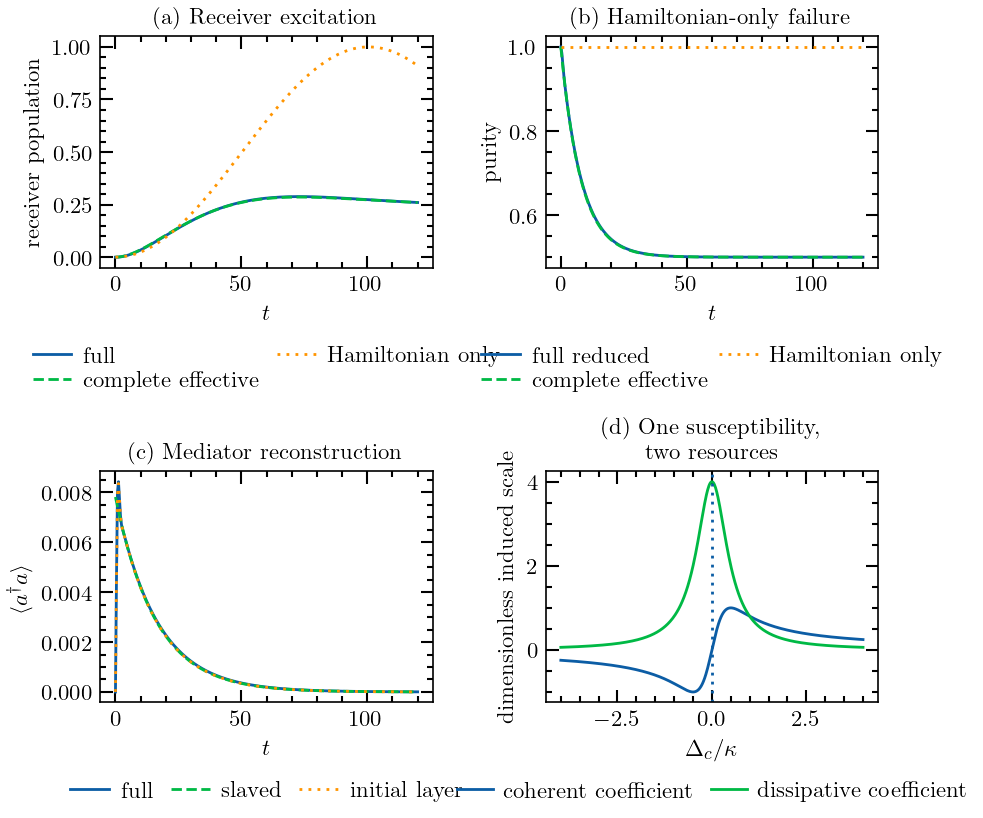

In [7]:
x = np.linspace(-4.0, 4.0, 501)
coherent_scaled = x / (x**2 + 0.25)
dissipative_scaled = 1.0 / (x**2 + 0.25)

susceptibility = pd.DataFrame({
    "detuning_over_kappa": x,
    "kappa_times_coherent_prefactor": coherent_scaled,
    "kappa_times_dissipative_prefactor": dissipative_scaled,
})
save_table(susceptibility, "N04_D5")

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 5.35))
gs = fig.add_gridspec(
    2, 2,
    left=0.11, right=0.988, bottom=0.11, top=0.94,
    hspace=0.88, wspace=0.34,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])

# ------------------------------------------------------------------
# (a) Receiver excitation
# ------------------------------------------------------------------

ax = axes[0, 0]

ax.plot(TIMES, receiver_full, label="full")
ax.plot(TIMES, receiver_eff, "--", label="complete effective")
ax.plot(
    TIMES, receiver_ham,
    linestyle=DOT_STYLE,
    label="Hamiltonian only",
)

ax.set(
    xlabel=r"$t$",
    ylabel="receiver population",
    title="(a) Receiver excitation",
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    ncol=2,
    handlelength=1.7,
    handletextpad=0.50,
    columnspacing=0.8,
    labelspacing=0.18,
    borderaxespad=0.0,
)


# ------------------------------------------------------------------
# (b) Purity
# ------------------------------------------------------------------

ax = axes[0, 1]

ax.plot(TIMES, purity_full, label="full reduced")
ax.plot(TIMES, purity_eff, "--", label="complete effective")
ax.plot(
    TIMES, purity_ham,
    linestyle=DOT_STYLE,
    label="Hamiltonian only",
)

ax.set(
    xlabel=r"$t$",
    ylabel="purity",
    title="(b) Hamiltonian-only failure",
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    ncol=2,
    handlelength=1.7,
    handletextpad=0.50,
    columnspacing=0.5,
    labelspacing=0.18,
    borderaxespad=0.0,
)


# ------------------------------------------------------------------
# (c) Mediator reconstruction
# ------------------------------------------------------------------

ax = axes[1, 0]

ax.plot(TIMES, cavity_full, label="full")
ax.plot(TIMES, slaved_population, "--", label="slaved")
ax.plot(
    TIMES, initial_layer_population,
    linestyle=DOT_STYLE,
    label="initial layer",
)

ax.set(
    xlabel=r"$t$",
    ylabel=r"$\langle a^\dagger a\rangle$",
    title="(c) Mediator reconstruction",
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    ncol=3,
    handlelength=1.7,
    handletextpad=0.50,
    columnspacing=0.8,
    labelspacing=0.18,
    borderaxespad=0.0,
)


# ------------------------------------------------------------------
# (d) Susceptibility
# ------------------------------------------------------------------

ax = axes[1, 1]

ax.plot(x, coherent_scaled, label="coherent coefficient")
ax.plot(x, dissipative_scaled, label="dissipative coefficient")
ax.axvline(
    0.0,
    linestyle=DOT_STYLE,
    linewidth=1.35,
)

ax.set(
    xlabel=r"$\Delta_c/\kappa$",
    ylabel="dimensionless induced scale",
    title="(d) One susceptibility,\ntwo resources",
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    frameon=False,
    ncol=2,
    handlelength=1.55,
    handletextpad=0.45,
    columnspacing=0.8,
    labelspacing=0.16,
    borderaxespad=0.0,
)


save_figure(fig, "N04_F8")
plt.show()
plt.close(fig)

**Notebook Figure N04_F8. Open-system resource view.**
The complete master equation is compared with the full model and a Hamiltonian-only
truncation at the level of receiver population and purity; the lower panels show
mediator reconstruction and the coherent--dissipative susceptibility crossover.
This preserves the compact manuscript-support figure used in earlier article drafts
while N04_MF2 provides the stricter state-resolved state-error benchmark.

## 13. Several slow transition frequencies

If
$$
F=\sum_\omega F_\omega,
\qquad
[H_S,F_\omega]=-\omega F_\omega,
$$
then
$$
\chi_c(\omega)
=
\frac{1}{-(\Delta_c+\omega)-i\kappa/2}.
$$

Before secularization a consistent time-dependent jump is
$$
L_{\rm eff}(t)
=
\sqrt{\kappa}
\sum_\omega
\chi_c(\omega)F_\omega e^{-i\omega t},
$$
with Kossakowski matrix
$$
\Gamma_{\omega\omega'}(t)
=
\kappa\chi_c(\omega)\chi_c^*(\omega')
e^{-i(\omega-\omega')t}.
$$
It is a Gram matrix and therefore positive semidefinite.

When transition separations are large compared with induced rates, full
secularization gives
$$
H_{\rm ind}^{\rm sec}
=
-\sum_\omega
\operatorname{Re}\chi_c(\omega)\,
F_\omega^\dagger F_\omega,
$$
$$
\dot\rho_S
=
-i[H_S+H_{\rm ind}^{\rm sec},\rho_S]
+
\sum_\omega
\kappa|\chi_c(\omega)|^2\,
\mathcal D[F_\omega]\rho_S.
$$

Partial secularization must retain coherent and dissipative cross terms as one block.
Mixing diagonal rates from one approximation with an unrelated cross rate can make
the Kossakowski matrix indefinite.

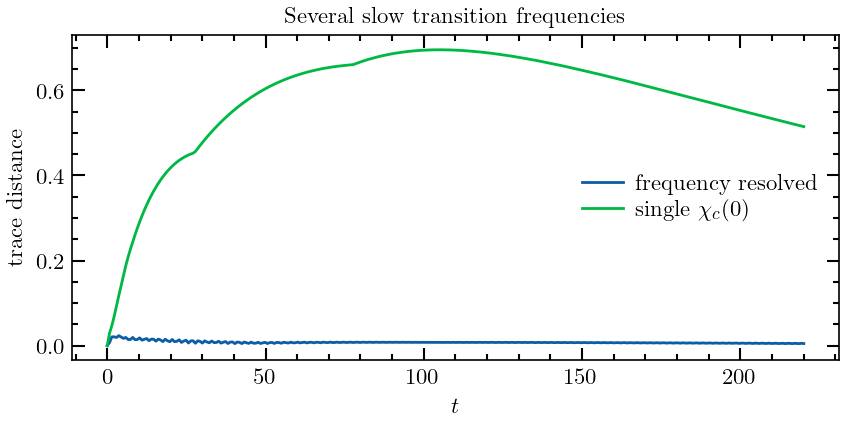

,quantity,value
0,mixing_parameter_transition_1,0.107331
1,mixing_parameter_transition_2,0.058209
2,max_trace_distance_frequency_resolved,0.023475
3,max_trace_distance_common_response,0.695065


In [8]:
# Nondegenerate two-frequency benchmark.
kappa_fr = 1.0
delta_fr = 0.5
omega1_fr = -1.5
omega2_fr = 1.5
g1_fr = 0.12
g2_fr = 0.12
Nc_fr = 3
times_fr = np.linspace(0.0, 220.0, 301)

fr = build_two_qubit_mediator(
    cavity_dim=Nc_fr,
    detuning=delta_fr,
    kappa=kappa_fr,
    g1=g1_fr,
    g2=g2_fr,
    omega1=omega1_fr,
    omega2=omega2_fr,
)

out_fr_full = mesolve(
    fr["H_full"],
    tensor(basis(Nc_fr, 0), E, E),
    times_fr,
    c_ops=fr["c_full"],
    options=SOLVER,
)
rho_fr_full = [state.ptrace([1, 2]) for state in out_fr_full.states]

sm1 = tensor(sigmam(), qeye(2))
sm2 = tensor(qeye(2), sigmam())
pe1 = tensor(P_E, qeye(2))
pe2 = tensor(qeye(2), P_E)
Hs_fr = omega1_fr * pe1 + omega2_fr * pe2

def chi_fr(omega):
    return 1.0 / (-(delta_fr + omega) - 0.5j * kappa_fr)

chi1 = chi_fr(omega1_fr)
chi2 = chi_fr(omega2_fr)
chi0 = chi_fr(0.0)

H_sec = (
    Hs_fr
    - np.real(chi1) * (g1_fr**2) * sm1.dag() * sm1
    - np.real(chi2) * (g2_fr**2) * sm2.dag() * sm2
)
c_sec = [
    np.sqrt(kappa_fr) * chi1 * g1_fr * sm1,
    np.sqrt(kappa_fr) * chi2 * g2_fr * sm2,
]

F_common = g1_fr * sm1 + g2_fr * sm2
H_common = Hs_fr - np.real(chi0) * F_common.dag() * F_common
c_common = [np.sqrt(kappa_fr) * chi0 * F_common]

out_sec = mesolve(H_sec, psi_slow_ee, times_fr, c_ops=c_sec, options=SOLVER)
out_common = mesolve(
    H_common, psi_slow_ee, times_fr, c_ops=c_common, options=SOLVER
)

err_sec = np.array([
    tracedist(a, b) for a, b in zip(rho_fr_full, out_sec.states)
])
err_common = np.array([
    tracedist(a, b) for a, b in zip(rho_fr_full, out_common.states)
])

frequency_resolved_summary = pd.DataFrame({
    "quantity": [
        "mixing_parameter_transition_1",
        "mixing_parameter_transition_2",
        "max_trace_distance_frequency_resolved",
        "max_trace_distance_common_response",
    ],
    "value": [
        g1_fr / abs(-(delta_fr + omega1_fr) - 0.5j * kappa_fr),
        g2_fr / abs(-(delta_fr + omega2_fr) - 0.5j * kappa_fr),
        err_sec.max(),
        err_common.max(),
    ],
})
save_table(frequency_resolved_summary, "N04_D6")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.10))
fig.subplots_adjust(left=0.12, right=0.985, bottom=0.18, top=0.88)
ax.plot(times_fr, err_sec, label="frequency resolved")
ax.plot(times_fr, err_common, label=r"single $\chi_c(0)$")
ax.set(
    xlabel=r"$t$",
    ylabel="trace distance",
    title="Several slow transition frequencies",
)
ax.legend(
    frameon=False, loc="center right",
    handlelength=1.8, handletextpad=0.55, labelspacing=0.20,
)
save_figure(fig, "N04_F1")
plt.show()
plt.close(fig)

frequency_resolved_summary

**Figure N04_F1.** A frequency-resolved secular reduction is compared with the
microscopic model and with a shortcut that evaluates both transitions using one
zero-frequency susceptibility. The latter can fail badly even when each individual
transition remains perturbative.

## 14. Generator physicality, finite-time Choi positivity, and an inconsistent hybrid

Complete positivity and quantitative accuracy are different questions.

For transition operators $A_i$, a dissipator
$$
\sum_{ij}C_{ij}
\left(
A_i\rho A_j^\dagger
-\frac12\{A_j^\dagger A_i,\rho\}
\right)
$$
is GKLS when $C\succeq0$.

The frequency-resolved nonsecular response at a fixed time has
$$
C_{ij}=\kappa\chi_i\chi_j^*,
$$
which is a Gram matrix. To show why the block structure matters, we also construct an
**inconsistent hybrid**: the diagonal rates are frequency resolved while the cross
rate is borrowed from $\chi_c(0)$. This is not a recommended approximation; it is
a deliberate counterexample.

### Composite-space convention

The two transition operators live in an explicit two-qubit tensor product. The
Liouville-space objects must preserve that subsystem structure as well. The
dissipator builder below therefore accumulates its superoperator directly from the
physical `spre`/`spost` terms rather than first creating a flattened four-level
identity. This is a QuTiP representation requirement; it does not modify the
Kossakowski matrix or the generator.


In [9]:
A_ops = [g1_fr * sm1, g2_fr * sm2]
chis = np.array([chi1, chi2], dtype=complex)

C_valid = kappa_fr * np.outer(chis, chis.conjugate())
cross_bad = kappa_fr * abs(chi0)**2
C_bad = np.array([
    [kappa_fr * abs(chi1)**2, cross_bad],
    [cross_bad, kappa_fr * abs(chi2)**2],
], dtype=complex)

def dissipator_from_kossakowski(ops, C):
    """Build a GKLS dissipator while preserving composite QuTiP dimensions.

    The superoperator is accumulated from the physical spre/spost terms
    themselves.  This avoids flattening a composite [2, 2] Hilbert space into
    a single [4] space when creating an artificial zero superoperator.
    """
    Dsuper = None
    for i, Ai in enumerate(ops):
        for j, Aj in enumerate(ops):
            term = C[i, j] * (
                spre(Ai) * spost(Aj.dag())
                - 0.5 * spre(Aj.dag() * Ai)
                - 0.5 * spost(Aj.dag() * Ai)
            )
            Dsuper = term if Dsuper is None else Dsuper + term
    if Dsuper is None:
        raise ValueError("At least one transition operator is required.")
    return Dsuper

D_valid = dissipator_from_kossakowski(A_ops, C_valid)
D_bad = dissipator_from_kossakowski(A_ops, C_bad)

superoperator_dimension_check = pd.DataFrame({
    "object": ["A_ops[0]", "D_valid", "D_bad"],
    "dims": [
        str(A_ops[0].dims),
        str(D_valid.dims),
        str(D_bad.dims),
    ],
})

dt_choi = 0.05
map_valid = (D_valid * dt_choi).expm()
map_bad = (D_bad * dt_choi).expm()

choi_valid = to_choi(map_valid)
choi_bad = to_choi(map_bad)

physicality = pd.DataFrame({
    "quantity": [
        "minimum_kossakowski_eigenvalue_valid",
        "minimum_kossakowski_eigenvalue_inconsistent",
        "minimum_choi_eigenvalue_valid",
        "minimum_choi_eigenvalue_inconsistent",
    ],
    "value": [
        np.min(np.linalg.eigvalsh(C_valid)),
        np.min(np.linalg.eigvalsh(C_bad)),
        np.min(np.real(choi_valid.eigenenergies())),
        np.min(np.real(choi_bad.eigenenergies())),
    ],
})
save_table(physicality, "N04_D7")
display(superoperator_dimension_check)
physicality


,object,dims
0,A_ops[0],"[[2, 2], [2, 2]]"
1,D_valid,"[[[2, 2], [2, 2]], [[2, 2], [2, 2]]]"
2,D_bad,"[[[2, 2], [2, 2]], [[2, 2], [2, 2]]]"


,quantity,value
0,minimum_kossakowski_eigenvalue_valid,-5.551115e-17
1,minimum_kossakowski_eigenvalue_inconsistent,-1.502185e+00
2,minimum_choi_eigenvalue_valid,-7.194337e-16
3,minimum_choi_eigenvalue_inconsistent,-2.163883e-03


A positive Kossakowski or Choi spectrum establishes physicality of the approximate
generator or map. It does **not** establish quantitative agreement with the
microscopic model; that still requires state, observable, steady-state, and spectral
benchmarks.

## 15. Slow spectral pole and perturbative order test

A useful linear benchmark is the bright--mediator no-jump block
$$
H_{\rm nh}^{(B)}
=
\begin{pmatrix}
0&G\\
G&-\Delta_c-i\kappa/2
\end{pmatrix}.
$$
The leading slow pole is
$$
\lambda_{\rm eff}
=
\frac{G^2}{\Delta_c+i\kappa/2}.
$$

For this **specific two-pole model**, the absolute slow-pole error scales as $G^4$
and the relative error as $G^2$ at weak coupling. This is a benchmark-specific
expansion, not a universal fourth-order theorem.

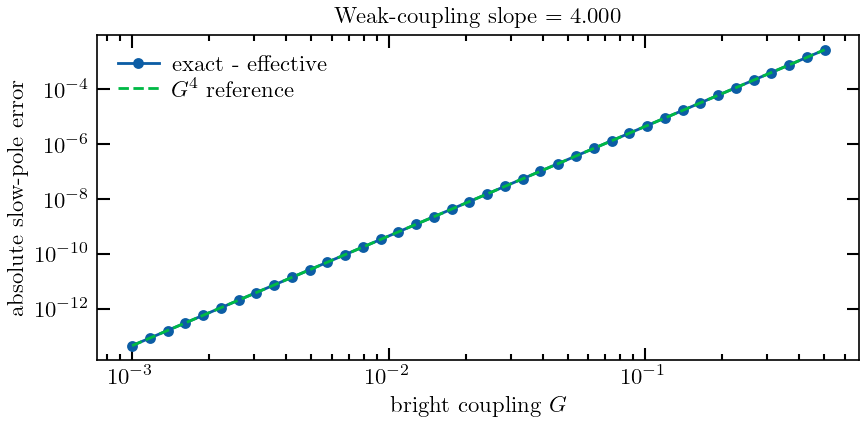

,bright_coupling,absolute_error,relative_error,weak_coupling_absolute_error_slope
0,0.001000,4.419417e-14,1.250000e-07,4.0
1,0.001173,8.361575e-14,1.719379e-07,4.0
2,0.001376,1.582017e-13,2.365011e-07,4.0
3,0.001613,2.993190e-13,3.253079e-07,4.0
4,0.001892,5.663140e-13,4.474620e-07,4.0


In [10]:
def exact_slow_pole(Gbright, detuning=2.0, kappa=4.0):
    H = Qobj([
        [0.0, Gbright],
        [Gbright, -detuning - 0.5j * kappa],
    ])
    eig = np.asarray(H.eigenenergies(), dtype=complex)
    return eig[np.argmin(np.abs(eig))]

G_grid = np.logspace(-3.0, -0.30, 40)
pole_rows = []
for Gbright in G_grid:
    exact = exact_slow_pole(Gbright)
    eff = Gbright**2 / (DELTA + 0.5j * KAPPA)
    pole_rows.append({
        "bright_coupling": Gbright,
        "absolute_error": abs(exact - eff),
        "relative_error": abs(exact - eff) / max(abs(exact), 1e-30),
    })

pole_table = pd.DataFrame(pole_rows)
fit_slice = slice(0, 25)
slope_abs = np.polyfit(
    np.log(pole_table["bright_coupling"].to_numpy()[fit_slice]),
    np.log(pole_table["absolute_error"].to_numpy()[fit_slice]),
    1,
)[0]
pole_table["weak_coupling_absolute_error_slope"] = slope_abs
save_table(pole_table, "N04_D8")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.10))
fig.subplots_adjust(left=0.125, right=0.985, bottom=0.18, top=0.88)
ax.loglog(
    pole_table["bright_coupling"],
    pole_table["absolute_error"],
    "o-",
    label="exact - effective",
)
reference = (
    pole_table["absolute_error"].iloc[5]
    * (G_grid / G_grid[5])**4
)
ax.loglog(G_grid, reference, "--", label=r"$G^4$ reference")
ax.set(
    xlabel=r"bright coupling $G$",
    ylabel="absolute slow-pole error",
    title=fr"Weak-coupling slope = {slope_abs:.3f}",
)
ax.legend(
    frameon=False, loc="upper left",
    handlelength=1.8, handletextpad=0.55, labelspacing=0.20,
)
save_figure(fig, "N04_F2")
plt.show()
plt.close(fig)

pole_table.head()

## 16. Fixed-slow-window validity map and the memory boundary

The local mixing scale is
$$
\eta_{\rm med}
=
\frac{\|F\|_{\mathcal M}}
{\sqrt{\Delta_c^2+\kappa^2/4}},
$$
where the norm is evaluated on the occupied slow manifold. Small local mixing is
necessary but not sufficient: induced slow rates must also remain small compared
with the complex fast gap.

The following map compares the exact $N_c=2$ cavity model with the complete
effective master equation over a fixed slow window
$$
\Gamma_B t\leq 3.
$$
Because the benchmark begins with one excitation, $N_c=2$ is exactly sufficient
for this particular map; a genuine bosonic cutoff test is performed separately in
Section 17.

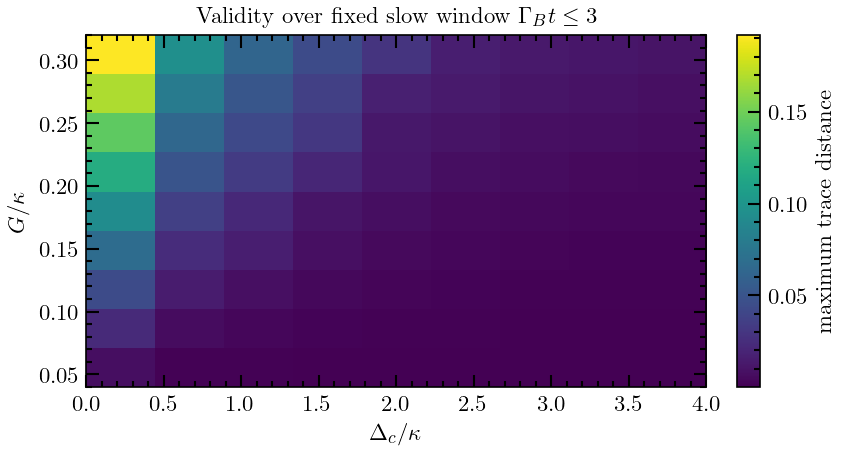

In [11]:
def validity_point(detuning_over_kappa, G_over_kappa, tau_max=3.0):
    kappa = 1.0
    detuning = detuning_over_kappa
    Gbright = G_over_kappa
    g = Gbright / np.sqrt(2.0)

    den = detuning**2 + 0.25
    gamma_B = kappa * Gbright**2 / den
    tmax = tau_max / max(gamma_B, 1e-12)
    times = np.linspace(0.0, tmax, 61)

    model = build_two_qubit_mediator(
        cavity_dim=2,
        detuning=detuning,
        kappa=kappa,
        g1=g,
        g2=g,
    )
    full = mesolve(
        model["H_full"],
        full_initial_state(2),
        times,
        c_ops=model["c_full"],
        options=SOLVER,
    )
    eff = mesolve(
        model["H_eff"],
        psi_slow_eg,
        times,
        c_ops=[model["L_eff"]],
        options=SOLVER,
    )
    reduced = [state.ptrace([1, 2]) for state in full.states]
    error = max(
        tracedist(a, b)
        for a, b in zip(reduced, eff.states)
    )

    return {
        "detuning_over_kappa": detuning_over_kappa,
        "bright_coupling_over_kappa": G_over_kappa,
        "mixing_parameter": Gbright / np.sqrt(den),
        "max_trace_distance": error,
        "slow_window_tmax": tmax,
    }

detuning_grid = np.linspace(0.0, 4.0, 9)
G_grid_map = np.linspace(0.04, 0.32, 9)

validity_rows = [
    validity_point(detuning, Gbright)
    for Gbright in G_grid_map
    for detuning in detuning_grid
]
validity_map = pd.DataFrame(validity_rows)
save_table(validity_map, "N04_D9")

error_matrix = validity_map.pivot(
    index="bright_coupling_over_kappa",
    columns="detuning_over_kappa",
    values="max_trace_distance",
).to_numpy()

fig = plt.figure(figsize=(FIG_WIDTH_150MM, 3.35))
ax = fig.add_axes([0.12, 0.18, 0.70, 0.70])
cax = fig.add_axes([0.855, 0.18, 0.026, 0.70])
im = ax.imshow(
    error_matrix,
    origin="lower",
    aspect="auto",
    extent=[
        detuning_grid.min(),
        detuning_grid.max(),
        G_grid_map.min(),
        G_grid_map.max(),
    ],
)
ax.set(
    xlabel=r"$\Delta_c/\kappa$",
    ylabel=r"$G/\kappa$",
    title=r"Validity over fixed slow window $\Gamma_Bt\leq3$",
)
fig.colorbar(im, cax=cax, label="maximum trace distance")
save_figure(fig, "N04_F3")
plt.show()
plt.close(fig)

**Figure N04_F3.** The elimination becomes unreliable as the mediator ceases to be
fast relative to the retained dynamics. The repair is structural: retain the
mediator, retain the relevant mode cluster, or use a memory kernel or finite-time
map.

## 17. Genuine bosonic cutoff convergence

The single-excitation two-qubit benchmark cannot test the unbounded bosonic
manifold: before loss, one total excitation is conserved, so a two-level mediator
already contains the exact occupied cavity sector.

A separate stress test therefore couples the lossy mediator to a **slow bosonic
mode initially in a coherent state**. The mediator cutoff $N_c$ is increased while
the slow-mode cutoff is held fixed. The reduced slow states are compared with the
largest-$N_c$ reference, and the population of the highest retained mediator Fock
state is monitored.

In the convergence figure, $N_c=6$ is the reference calculation and is therefore
not plotted as a zero error against itself. Its highest-Fock-level population is
still shown in the tail diagnostic.


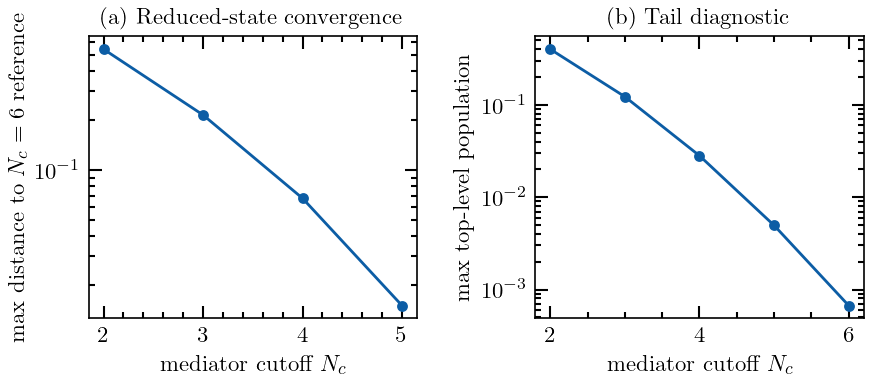

,mediator_cutoff,max_trace_distance_to_Nc6,max_top_fock_population
0,2,0.539470,0.402163
1,3,0.215394,0.122911
2,4,0.067316,0.028174
3,5,0.015062,0.004950
4,6,0.000000,0.000669


In [12]:
Ns = 8
alpha_cut = 1.5
g_cut = 0.50
delta_cut = 0.5
kappa_cut = 0.8
times_cut = np.linspace(0.0, 8.0, 81)
cutoffs = [2, 3, 4, 5, 6]

def bosonic_cutoff_run(Nc):
    a = tensor(destroy(Nc), qeye(Ns))
    b = tensor(qeye(Nc), destroy(Ns))
    H = (
        -delta_cut * a.dag() * a
        + g_cut * (a.dag() * b + a * b.dag())
    )
    psi0 = tensor(basis(Nc, 0), coherent(Ns, alpha_cut))
    out = mesolve(
        H,
        psi0,
        times_cut,
        c_ops=[np.sqrt(kappa_cut) * a],
        options=SOLVER,
    )
    reduced = [state.ptrace(1) for state in out.states]
    top = tensor(
        ket2dm(basis(Nc, Nc - 1)),
        qeye(Ns),
    )
    top_population = np.asarray(expect(top, out.states), dtype=float)
    return reduced, top_population

cutoff_runs = {}
for Nc_value in cutoffs:
    cutoff_runs[Nc_value] = bosonic_cutoff_run(Nc_value)

reference_states = cutoff_runs[cutoffs[-1]][0]
cutoff_rows = []
for Nc_value in cutoffs:
    reduced, top_population = cutoff_runs[Nc_value]
    max_distance = max(
        tracedist(a, b)
        for a, b in zip(reduced, reference_states)
    )
    cutoff_rows.append({
        "mediator_cutoff": Nc_value,
        "max_trace_distance_to_Nc6": max_distance,
        "max_top_fock_population": top_population.max(),
    })

cutoff_table = pd.DataFrame(cutoff_rows)
save_table(cutoff_table, "N04_D10")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 2.85))
fig.subplots_adjust(left=0.11, right=0.985, bottom=0.20, top=0.86, wspace=0.36)

# N_c=6 defines the reference state, so its distance to itself is not a
# convergence datum and is omitted from the logarithmic error curve.
comparison_cutoffs = cutoff_table.iloc[:-1]
axes[0].semilogy(
    comparison_cutoffs["mediator_cutoff"],
    comparison_cutoffs["max_trace_distance_to_Nc6"],
    "o-",
)
axes[0].set(
    xlabel=r"mediator cutoff $N_c$",
    ylabel=r"max distance to $N_c=6$ reference",
    title="(a) Reduced-state convergence",
)
axes[1].semilogy(
    cutoff_table["mediator_cutoff"],
    np.maximum(cutoff_table["max_top_fock_population"], 1e-15),
    "o-",
)
axes[1].set(
    xlabel=r"mediator cutoff $N_c$",
    ylabel="max top-level population",
    title="(b) Tail diagnostic",
)
save_figure(fig, "N04_F4")
plt.show()
plt.close(fig)

cutoff_table

## 18. Encoding: displaced, thermal, and squeezed mediator references

The vacuum reduction is not reference-state independent.

- A coherent fast reference should first be displaced, moving its mean field into
  the slow Hamiltonian and leaving fluctuations around the displaced vacuum.
- A stationary thermal reference has both positive- and negative-frequency
  correlations and therefore produces effective excitation as well as relaxation.
- A squeezed reference has anomalous correlations and can produce phase-sensitive
  effective channels.

It is important to distinguish a **thermal initial condition** from a **thermal fast
reference**. Preparing the mediator thermally at $t=0$ while coupling it to a
zero-temperature bath only creates an initial layer: the mediator subsequently
relaxes toward vacuum. A genuine thermal reference requires the fast Liouvillian
itself to have the thermal state as its stationary state.

For a mediator coupled to a thermal bath of occupation $\bar n$,
$$
L_-^{(c)}=\sqrt{\kappa(\bar n+1)}\,a,
\qquad
L_+^{(c)}=\sqrt{\kappa\bar n}\,a^\dagger .
$$
At one slow transition frequency, the corresponding reduced theory contains both
downward and upward slow channels. For the degenerate benchmark used here,
$$
L_\downarrow
=
\frac{\sqrt{\kappa(\bar n+1)}}{-\Delta_c-i\kappa/2}\,F,
\qquad
L_\uparrow
=
\frac{\sqrt{\kappa\bar n}}{\Delta_c-i\kappa/2}\,F^\dagger ,
$$
and
$$
H_{\rm ind}^{(T)}
=
\frac{\Delta_c}{\Delta_c^2+\kappa^2/4}
\left[
(\bar n+1)F^\dagger F-\bar n FF^\dagger
\right].
$$

The numerical test below compares three objects using the same thermal fast
Liouvillian: the full cavity model, the correctly encoded thermal reduction, and
the **unchanged vacuum reduction**. This directly tests the reference-state
assumption rather than conflating it with an initial transient.

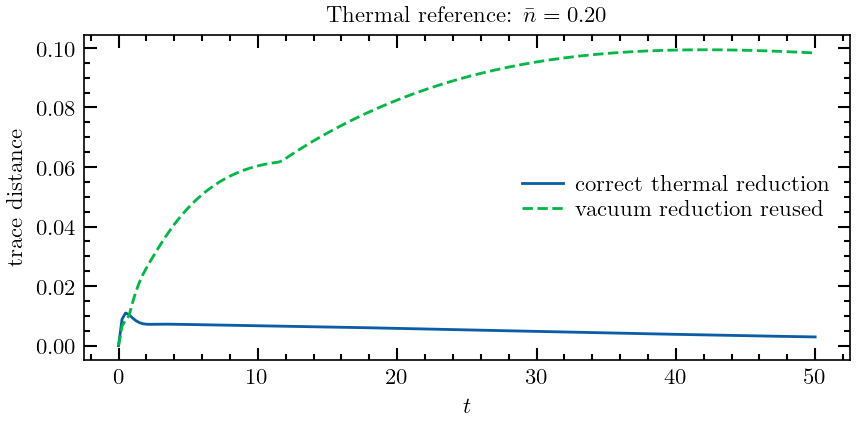

,quantity,value
0,thermal_bath_mean_occupation,0.200000
1,initial_mediator_occupation,0.199357
2,final_mediator_occupation,0.199607
3,max_error_correct_thermal_reduction,0.010975
4,max_error_using_vacuum_reduction,0.099371
5,thermal_encoding_improvement_factor,9.054516


In [13]:
Nc_th = 5
nbar_th = 0.20
times_th = np.linspace(0.0, 50.0, 201)

thermal_model = build_two_qubit_mediator(
    cavity_dim=Nc_th,
    detuning=DELTA,
    kappa=KAPPA,
    g1=G1,
    g2=G2,
)

a_th = thermal_model["a"]
F_th = thermal_model["F_slow"]
den_th = DELTA**2 + (KAPPA / 2.0)**2

# The fast Liouvillian itself has a thermal stationary state.
c_full_th = [
    np.sqrt(KAPPA * (nbar_th + 1.0)) * a_th,
    np.sqrt(KAPPA * nbar_th) * a_th.dag(),
]
rho0_th = tensor(
    thermal_dm(Nc_th, nbar_th),
    ket2dm(E),
    ket2dm(G),
)

out_th_full = mesolve(
    thermal_model["H_full"],
    rho0_th,
    times_th,
    c_ops=c_full_th,
    options=SOLVER,
)
rho_th_full_slow = [
    as_two_qubit_dm(state.ptrace([1, 2]))
    for state in out_th_full.states
]

# Correct thermal reduction: both relaxation and excitation are retained.
H_ind_th = (
    DELTA / den_th
    * (
        (nbar_th + 1.0) * F_th.dag() * F_th
        - nbar_th * F_th * F_th.dag()
    )
)
H_eff_th = thermal_model["H_slow"] + H_ind_th
L_down_th = (
    np.sqrt(KAPPA * (nbar_th + 1.0))
    / (-DELTA - 0.5j * KAPPA)
    * F_th
)
L_up_th = (
    np.sqrt(KAPPA * nbar_th)
    / (DELTA - 0.5j * KAPPA)
    * F_th.dag()
)

out_th_correct = mesolve(
    H_eff_th,
    psi_slow_eg,
    times_th,
    c_ops=[L_down_th, L_up_th],
    options=SOLVER,
)
rho_th_correct = [
    as_two_qubit_dm(state)
    for state in out_th_correct.states
]

# Deliberately wrong comparison: reuse the vacuum reduction unchanged.
out_th_vacuum = mesolve(
    thermal_model["H_eff"],
    psi_slow_eg,
    times_th,
    c_ops=[thermal_model["L_eff"]],
    options=SOLVER,
)
rho_th_vacuum = [
    as_two_qubit_dm(state)
    for state in out_th_vacuum.states
]

thermal_correct_error = np.array([
    tracedist(a, b)
    for a, b in zip(rho_th_full_slow, rho_th_correct)
])
thermal_vacuum_error = np.array([
    tracedist(a, b)
    for a, b in zip(rho_th_full_slow, rho_th_vacuum)
])

n_th_full = np.asarray(
    expect(a_th.dag() * a_th, out_th_full.states),
    dtype=float,
)

thermal_summary = pd.DataFrame({
    "quantity": [
        "thermal_bath_mean_occupation",
        "initial_mediator_occupation",
        "final_mediator_occupation",
        "max_error_correct_thermal_reduction",
        "max_error_using_vacuum_reduction",
        "thermal_encoding_improvement_factor",
    ],
    "value": [
        nbar_th,
        n_th_full[0],
        n_th_full[-1],
        thermal_correct_error.max(),
        thermal_vacuum_error.max(),
        thermal_vacuum_error.max()
        / max(thermal_correct_error.max(), 1e-15),
    ],
})
save_table(thermal_summary, "N04_D11")

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.10))
fig.subplots_adjust(left=0.12, right=0.985, bottom=0.18, top=0.88)
ax.plot(times_th, thermal_correct_error, label="correct thermal reduction")
ax.plot(times_th, thermal_vacuum_error, "--", label="vacuum reduction reused")
ax.set(
    xlabel=r"$t$",
    ylabel="trace distance",
    title=r"Thermal reference: $\bar n=0.20$",
)
ax.legend(
    frameon=False, loc="center right",
    handlelength=1.8, handletextpad=0.55, labelspacing=0.20,
)
save_figure(fig, "N04_F5")
plt.show()
plt.close(fig)

thermal_summary

## 19. Nonlinear reservoir engineering and synchronization

A linear vertex
$$
a^\dagger F+aF^\dagger
$$
produces a jump proportional to $F$ at this order. Nonlinear reservoirs require a
nonlinear target operator or another mixing process. For example,
$$
H_{\rm int}
=
g_2(a^\dagger b^2+a\,b^{\dagger2})
$$
produces
$$
L_{\rm eff}\propto b^2
$$
after eliminating $a$. Driving or displacing the auxiliary can shift the jump to
a form such as
$$
L_{\rm eff}\propto b^2-\alpha^2,
$$
while higher-wave-mixing processes can generate number-selective higher-photon
channels.

Two-photon loss also appears in quantum van der Pol models,
$$
\dot\rho
=
-i[H,\rho]
+\gamma_1\mathcal D[b^\dagger]\rho
+\gamma_2\mathcal D[b^2]\rho,
$$
where linear gain destabilizes the vacuum and nonlinear loss limits the amplitude,
creating a quantum limit cycle. Weak driving or coupling to another oscillator can
then synchronize a phase or relative phase.

The design lesson is the same as in the linear calculation: the intended jump,
its coherent companion, and residual nonlinear corrections must be derived together.

## 20. Conditional non-Hermitian dynamics versus the full Liouvillian

For collapse operators $L_\mu$,
$$
H_{\rm nh}
=
H-\frac{i}{2}\sum_\mu L_\mu^\dagger L_\mu
$$
governs trajectories conditioned on the absence of monitored jumps. The unconditional
generator is
$$
\mathcal L\rho
=
-i(H_{\rm nh}\rho-\rho H_{\rm nh}^\dagger)
+
\sum_\mu L_\mu\rho L_\mu^\dagger.
$$

The recycling terms can change both eigenvalues and eigenmodes. An exceptional point
of $H_{\rm nh}$ is therefore not generally an exceptional point of the full
Liouvillian. A Liouvillian exceptional point requires coalescence and defectiveness
of the superoperator itself.

The minimal bright--mediator amplitude-damping model below is a useful special case:
the conditional and Liouvillian defectiveness diagnostics can peak near the same
coupling. That coincidence is model dependent and should not be promoted to a
general equivalence.

The condition-number scan is supplemented by a direct rank test at
$G=\kappa/4$. In this special three-state model the Liouvillian has repeated
eigenvalues at $-\kappa/4$ and $-\kappa/2$, each with algebraic multiplicity
four but geometric multiplicity two. The superoperator is therefore genuinely
defective at the same coupling as the conditional two-state block. This remains a
property of this model, not a general identity between conditional and Liouvillian
exceptional points.


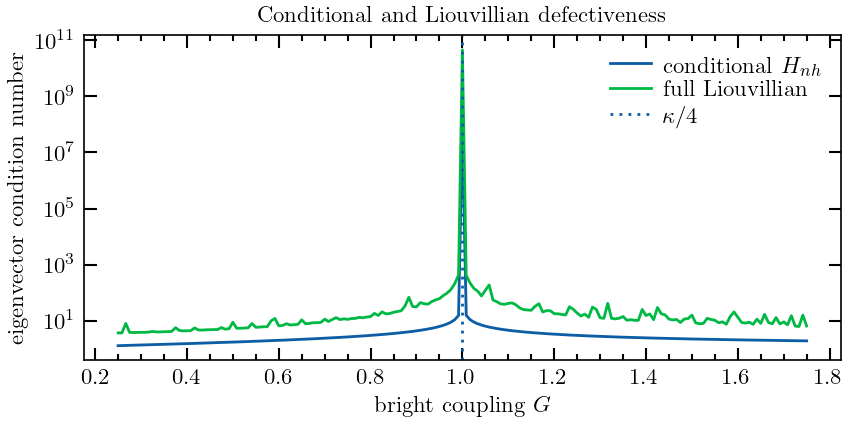

,quantity,value
0,conditional_EP_G,1.0
1,liouvillian_geometric_mult_at_minus_kappa_over_4,2.0
2,liouvillian_geometric_mult_at_minus_kappa_over_2,2.0
3,expected_algebraic_mult_each_repeated_liouvill...,4.0


In [14]:
kappa_ep = 4.0
G_ep = np.linspace(0.25, 1.75, 181)

cond_rows = []
for Gbright in G_ep:
    # Conditional bright--mediator block.
    Hnh = np.array([
        [0.0, Gbright],
        [Gbright, -0.5j * kappa_ep],
    ], dtype=complex)
    _, Vnh = np.linalg.eig(Hnh)
    cond_number_nh = np.linalg.cond(Vnh)

    # Full three-state amplitude-damping model: |B>, |c>, |g>.
    B3 = basis(3, 0)
    C3 = basis(3, 1)
    G3 = basis(3, 2)
    H3 = Gbright * (B3 * C3.dag() + C3 * B3.dag())
    c3 = [np.sqrt(kappa_ep) * G3 * C3.dag()]
    L3 = liouvillian(H3, c3)
    _, Vliouv = np.linalg.eig(L3.full())
    cond_number_L = np.linalg.cond(Vliouv)

    cond_rows.append({
        "bright_coupling": Gbright,
        "conditional_condition_number": cond_number_nh,
        "liouvillian_condition_number": cond_number_L,
    })

ep_table = pd.DataFrame(cond_rows)
save_table(ep_table, "N04_D12")

G_peak_nh = ep_table.loc[
    ep_table["conditional_condition_number"].idxmax(),
    "bright_coupling",
]
G_peak_L = ep_table.loc[
    ep_table["liouvillian_condition_number"].idxmax(),
    "bright_coupling",
]

fig, ax = plt.subplots(figsize=(FIG_WIDTH_150MM, 3.10))
fig.subplots_adjust(left=0.13, right=0.985, bottom=0.18, top=0.88)
ax.semilogy(
    ep_table["bright_coupling"],
    ep_table["conditional_condition_number"],
    label=r"conditional $H_{nh}$",
)
ax.semilogy(
    ep_table["bright_coupling"],
    ep_table["liouvillian_condition_number"],
    label="full Liouvillian",
)
ax.axvline(
    kappa_ep / 4.0,
    linestyle=DOT_STYLE,
    linewidth=1.35,
    label=r"$\kappa/4$",
)
ax.set(
    xlabel=r"bright coupling $G$",
    ylabel="eigenvector condition number",
    title="Conditional and Liouvillian defectiveness",
)
ax.legend(
    frameon=False, loc="upper right",
    handlelength=1.8, handletextpad=0.55, labelspacing=0.20,
)
save_figure(fig, "N04_F6")
plt.show()
plt.close(fig)

pd.DataFrame({
    "quantity": ["conditional_peak_G", "liouvillian_peak_G"],
    "value": [G_peak_nh, G_peak_L],
})

# Direct defectiveness check at the analytically known conditional EP G=kappa/4.
G_exact_ep = kappa_ep / 4.0
B3 = basis(3, 0)
C3 = basis(3, 1)
G3 = basis(3, 2)
H3_ep = G_exact_ep * (B3 * C3.dag() + C3 * B3.dag())
L3_ep = liouvillian(
    H3_ep,
    [np.sqrt(kappa_ep) * G3 * C3.dag()],
)
L3_array = L3_ep.full()

def geometric_multiplicity(matrix, eigenvalue, tol=1e-9):
    shifted = matrix - eigenvalue * np.eye(matrix.shape[0], dtype=complex)
    return matrix.shape[0] - np.linalg.matrix_rank(shifted, tol=tol)

# For this model the Liouvillian characteristic polynomial at the EP has
# eigenvalues -kappa/4 and -kappa/2 with algebraic multiplicity four each.
geom_minus_quarter = geometric_multiplicity(
    L3_array, -kappa_ep / 4.0
)
geom_minus_half = geometric_multiplicity(
    L3_array, -kappa_ep / 2.0
)

ep_defectiveness = pd.DataFrame({
    "quantity": [
        "conditional_EP_G",
        "liouvillian_geometric_mult_at_minus_kappa_over_4",
        "liouvillian_geometric_mult_at_minus_kappa_over_2",
        "expected_algebraic_mult_each_repeated_liouvillian_eigenvalue",
    ],
    "value": [
        G_exact_ep,
        geom_minus_quarter,
        geom_minus_half,
        4,
    ],
})
save_table(ep_defectiveness, "N04_D12b")
display(ep_defectiveness)


## 21. Saturable baseline: eliminating a lossy qubit

A lossy two-level auxiliary is not an unbounded harmonic mode. At weak excitation it
can reproduce the same complex-response structure, but stronger driving reveals
saturation of its finite excited manifold.

As a compact comparison, a slow bosonic mode $b$ is coupled to a fast decaying
qubit,
$$
H
=
-\Delta_q\sigma_+\sigma_-
+
g(b^\dagger\sigma_-+b\sigma_+),
\qquad
L_q=\sqrt{\gamma_q}\,\sigma_- .
$$
The weak-excitation reduction gives
$$
H_{\rm ind}^{(q)}
=
\frac{\Delta_qg^2}{\Delta_q^2+\gamma_q^2/4}\,b^\dagger b,
\qquad
L_{\rm eff}^{(q)}
=
\frac{\sqrt{\gamma_q}g}{-\Delta_q-i\gamma_q/2}\,b.
$$
The comparison below uses a low-occupation and a higher-occupation coherent state to
make the saturation mechanism visible.

In [15]:
Nb_q = 9
delta_q = 2.0
gamma_q = 4.0
g_q = 0.8
times_q = np.linspace(0.0, 25.0, 151)

b_full = tensor(destroy(Nb_q), qeye(2))
sm_q = tensor(qeye(Nb_q), sigmam())
pe_q = tensor(qeye(Nb_q), P_E)

H_q_full = (
    -delta_q * pe_q
    + g_q * (b_full.dag() * sm_q + b_full * sm_q.dag())
)
c_q_full = [np.sqrt(gamma_q) * sm_q]

b_slow = destroy(Nb_q)
den_q = delta_q**2 + (gamma_q / 2.0)**2
H_q_eff = delta_q * g_q**2 / den_q * b_slow.dag() * b_slow
L_q_eff = (
    np.sqrt(gamma_q) * g_q
    / (-delta_q - 0.5j * gamma_q)
    * b_slow
)

lossy_qubit_rows = []
for alpha_q in [0.35, 1.50]:
    psi_full_q = tensor(coherent(Nb_q, alpha_q), G)
    psi_slow_q = coherent(Nb_q, alpha_q)

    full_q = mesolve(
        H_q_full,
        psi_full_q,
        times_q,
        c_ops=c_q_full,
        options=SOLVER,
    )
    eff_q = mesolve(
        H_q_eff,
        psi_slow_q,
        times_q,
        c_ops=[L_q_eff],
        options=SOLVER,
    )
    reduced_q = [state.ptrace(0) for state in full_q.states]
    err_q = np.array([
        tracedist(a, b)
        for a, b in zip(reduced_q, eff_q.states)
    ])
    excitation_q = np.asarray(expect(pe_q, full_q.states), dtype=float)

    lossy_qubit_rows.append({
        "alpha": alpha_q,
        "initial_mean_boson_number": abs(alpha_q)**2,
        "max_trace_distance": err_q.max(),
        "max_fast_qubit_excitation": excitation_q.max(),
    })

lossy_qubit_table = pd.DataFrame(lossy_qubit_rows)
save_table(lossy_qubit_table, "N04_D13")
lossy_qubit_table

,alpha,initial_mean_boson_number,max_trace_distance,max_fast_qubit_excitation
0,0.35,0.1225,0.024350,0.008953
1,1.50,2.2500,0.173716,0.135407


The bosonic and qubit auxiliaries share the complex-response logic, but only the
two-level auxiliary saturates. This baseline prevents auxiliary-specific nonlinear
effects from being mistaken for universal properties of adiabatic elimination.

## 22. First structural failure: retain the mediator

When the mediator is weakly damped and nearly resonant, it stores population and
phase information on the same scale as the retained subsystem. A single
time-independent slow generator then misses transient storage, oscillatory memory,
and revivals.

The correct repair is not “go to a higher order” while keeping the same retained
space. One should instead retain the mediator or relevant mode cluster, or use a
memory kernel or finite-time map.

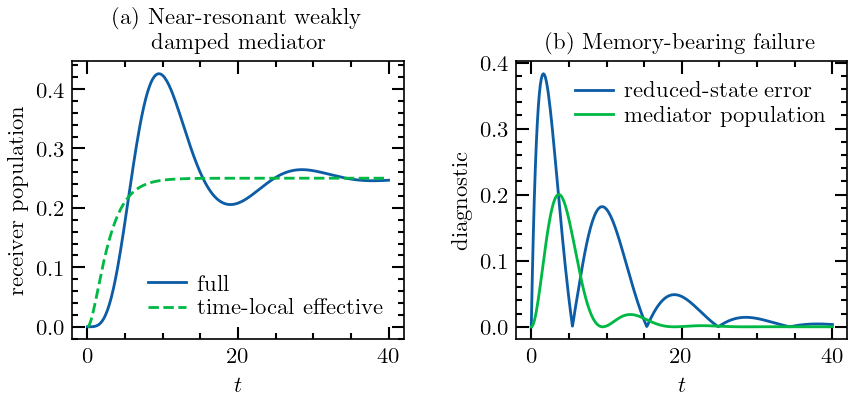

,quantity,value
0,mixing_parameter,1.414214
1,max_trace_distance,0.383072
2,max_mediator_population,0.200328


In [16]:
delta_bad = 0.0
kappa_bad = 0.5
g_bad = 0.25
times_bad = np.linspace(0.0, 40.0, 301)

bad = build_two_qubit_mediator(
    cavity_dim=3,
    detuning=delta_bad,
    kappa=kappa_bad,
    g1=g_bad,
    g2=g_bad,
)
full_bad = mesolve(
    bad["H_full"],
    full_initial_state(3),
    times_bad,
    c_ops=bad["c_full"],
    options=SOLVER,
)
eff_bad = mesolve(
    bad["H_eff"],
    psi_slow_eg,
    times_bad,
    c_ops=[bad["L_eff"]],
    options=SOLVER,
)
rho_bad = [state.ptrace([1, 2]) for state in full_bad.states]

error_bad = np.array([
    tracedist(a, b)
    for a, b in zip(rho_bad, eff_bad.states)
])
mediator_bad = np.asarray(
    expect(bad["a"].dag() * bad["a"], full_bad.states),
    dtype=float,
)
receiver_bad_full = np.asarray(
    expect(bad["receiver_full"], full_bad.states),
    dtype=float,
)
receiver_bad_eff = np.asarray(
    expect(bad["receiver_slow"], eff_bad.states),
    dtype=float,
)

breakdown_summary = pd.DataFrame({
    "quantity": [
        "mixing_parameter",
        "max_trace_distance",
        "max_mediator_population",
    ],
    "value": [
        np.sqrt(2) * g_bad
        / np.sqrt(delta_bad**2 + (kappa_bad / 2.0)**2),
        error_bad.max(),
        mediator_bad.max(),
    ],
})
save_table(breakdown_summary, "N04_D14")

fig, axes = plt.subplots(1, 2, figsize=(FIG_WIDTH_150MM, 2.90))
fig.subplots_adjust(left=0.11, right=0.985, bottom=0.20, top=0.84, wspace=0.34)
axes[0].plot(times_bad, receiver_bad_full, label="full")
axes[0].plot(times_bad, receiver_bad_eff, "--", label="time-local effective")
axes[0].set(
    xlabel=r"$t$",
    ylabel="receiver population",
    title="(a) Near-resonant weakly\ndamped mediator",
)
axes[0].legend(
    frameon=False, loc="lower right",
    handlelength=1.65, handletextpad=0.50, labelspacing=0.18,
)

axes[1].plot(times_bad, error_bad, label="reduced-state error")
axes[1].plot(times_bad, mediator_bad, label="mediator population")
axes[1].set(
    xlabel=r"$t$",
    ylabel="diagnostic",
    title="(b) Memory-bearing failure",
)
axes[1].legend(
    frameon=False, loc="upper right",
    handlelength=1.65, handletextpad=0.50, labelspacing=0.18,
)
save_figure(fig, "N04_F7")
plt.show()
plt.close(fig)

breakdown_summary

## 23. Validation ledger and common incorrect shortcuts

The most common shortcuts in this application are:

1. **complex Hamiltonian = master equation:** false for unconditional dynamics,
   because recycling terms are missing;
2. **small mediator population = accurate reduced state:** not sufficient; phase and
   dissipative errors can accumulate while the mediator remains weakly occupied;
3. **one cavity cutoff is enough:** only if sector structure proves it; otherwise a
   genuine multi-excitation convergence test is required;
4. **vacuum formula works for a thermal or squeezed mediator:** false without a
   changed encoding/correlation model;
5. **positive map = accurate map:** complete positivity is a physicality test, not an
   accuracy test;
6. **non-Hermitian EP = Liouvillian EP:** not in general;
7. **higher order repairs a closed fast gap:** false; the retained space must change.

In [17]:
# Liouvillian spectral audit of the controlled baseline.
L_eff_baseline = liouvillian(
    baseline["H_eff"],
    [baseline["L_eff"]],
)
eig_L = np.asarray(L_eff_baseline.eigenenergies(), dtype=complex)
zero_mode_count = int(np.sum(np.abs(eig_L) < 1e-9))
nonzero_decay = -np.real(eig_L[np.real(eig_L) < -1e-9])
liouvillian_gap = np.min(nonzero_decay) if len(nonzero_decay) else np.nan

trace_residual = max(abs(state.tr() - 1.0) for state in out_eff.states)
hermiticity_residual = max((state - state.dag()).norm() for state in out_eff.states)

validation = pd.DataFrame({
    "check": [
        "trace preservation",
        "Hermiticity preservation",
        "complete reduction accurate",
        "Hamiltonian-only failure visible",
        "dark-state annihilation",
        "dark-mixture concurrence",
        "initial-layer reconstruction improves",
        "frequency-resolved model beats common response",
        "valid Kossakowski matrix PSD",
        "inconsistent Kossakowski matrix non-PSD",
        "valid finite-time map Choi positive",
        "inconsistent finite-time map Choi non-positive",
        "slow-pole weak-coupling slope near four",
        "genuine bosonic cutoff improves",
        "correct thermal encoding beats reused vacuum model",
        "thermal reduction remains controlled",
        "lossy-qubit saturation increases error",
        "conditional and Liouvillian EP peaks coincide in special model",
        "Liouvillian rank test shows defectiveness",
        "closing-gap regime fails more strongly",
        "Liouvillian dark-manifold zero modes",
    ],
    "value": [
        trace_residual,
        hermiticity_residual,
        trace_eff.max(),
        trace_ham.max(),
        (baseline["L_eff"] * D).norm(),
        bright_dark_checks.loc[
            bright_dark_checks["quantity"] == "ideal_dark_mixture_concurrence",
            "value",
        ].iloc[0],
        reconstruction_summary.loc[
            reconstruction_summary["quantity"] == "improvement_factor",
            "value",
        ].iloc[0],
        err_sec.max() < err_common.max(),
        np.min(np.linalg.eigvalsh(C_valid)),
        np.min(np.linalg.eigvalsh(C_bad)),
        np.min(np.real(choi_valid.eigenenergies())),
        np.min(np.real(choi_bad.eigenenergies())),
        slope_abs,
        cutoff_table.iloc[-2]["max_trace_distance_to_Nc6"]
        < cutoff_table.iloc[0]["max_trace_distance_to_Nc6"],
        thermal_correct_error.max() < thermal_vacuum_error.max(),
        thermal_correct_error.max(),
        lossy_qubit_table.iloc[1]["max_trace_distance"]
        > lossy_qubit_table.iloc[0]["max_trace_distance"],
        abs(G_peak_nh - G_peak_L),
        (geom_minus_quarter < 4) and (geom_minus_half < 4),
        error_bad.max() > trace_eff.max(),
        zero_mode_count,
    ],
})
save_table(validation, "N04_D15")

assert trace_residual < 1e-8
assert hermiticity_residual < 1e-8
assert trace_eff.max() < 0.03
assert trace_ham.max() > 0.4
assert (baseline["L_eff"] * D).norm() < 1e-12
assert abs(bright_dark_checks.iloc[2]["value"] - 0.5) < 1e-12
assert reconstruction_summary.iloc[2]["value"] > 2.0
assert err_sec.max() < err_common.max()
assert np.min(np.linalg.eigvalsh(C_valid)) > -1e-12
assert np.min(np.linalg.eigvalsh(C_bad)) < -1e-6
assert np.min(np.real(choi_valid.eigenenergies())) > -1e-9
assert np.min(np.real(choi_bad.eigenenergies())) < -1e-6
assert 3.4 < slope_abs < 4.6
assert cutoff_table.iloc[-2]["max_trace_distance_to_Nc6"] < cutoff_table.iloc[0]["max_trace_distance_to_Nc6"]
assert thermal_correct_error.max() < thermal_vacuum_error.max()
assert thermal_correct_error.max() < 0.03
assert lossy_qubit_table.iloc[1]["max_trace_distance"] > 3.0 * lossy_qubit_table.iloc[0]["max_trace_distance"]
assert abs(G_peak_nh - G_peak_L) < 0.05
assert geom_minus_quarter < 4
assert geom_minus_half < 4
assert error_bad.max() > trace_eff.max()
assert zero_mode_count >= 2

validation


,check,value
0,trace preservation,0.0
1,Hermiticity preservation,0.0
2,complete reduction accurate,0.009366
3,Hamiltonian-only failure visible,0.797663
4,dark-state annihilation,0.0
5,dark-mixture concurrence,0.5
6,initial-layer reconstruction improves,85.194128
7,frequency-resolved model beats common response,True
8,valid Kossakowski matrix PSD,-0.0
9,inconsistent Kossakowski matrix non-PSD,-1.502185


## 24. Exercises and independent investigations

### Derivation and method exercises

1. Starting from the effective-operator formulas, derive $H_{\rm ind}$ and
   $L_{\rm eff}$ for the vacuum mediator.
2. Derive the same single-frequency result from the Langevin equation, keeping the
   homogeneous transient and input-noise term separate.
3. Perform the far-detuned small rotation and show how the cavity collapse operator
   transforms together with the Hamiltonian.
4. Carry out the James--Jerke second-order coherent average and identify precisely
   which open-system information it does not supply by itself.
5. Starting from
   $P\mathcal LP-P\mathcal LQ(Q\mathcal LQ)^{-1}Q\mathcal LP$,
   identify the fast inverse that becomes the susceptibility.

### Frequency resolution and physicality

6. Repeat the nondegenerate benchmark with a smaller transition separation and decide
   whether full, partial, or no secularization is appropriate.
7. Construct the time-dependent two-frequency Kossakowski matrix and verify its Gram
   structure.
8. Deliberately vary the inconsistent hybrid cross rate until the minimum Choi
   eigenvalue first becomes negative.
9. Compare the Liouvillian gap with the maximum state error across the validity map.

### Reconstruction and retained-space choices

10. Use QuTiP two-time correlations to reconstruct the mediator occupation for a
    mixed slow initial state.
11. Prepare the mediator in a coherent state, perform the displacement explicitly,
    and compare with the undisplaced vacuum reduction.
12. Replace the thermal mediator by a squeezed reference and identify the anomalous
    correlations required in the reduced generator.
13. In the failing near-resonant regime, retain the mediator as part of the slow
    model and compare this enlarged retained description with the eliminated one.
14. Derive an explicit memory kernel for the bright--mediator sector.

### Nonlinear and auxiliary-statistics extensions

15. Starting from
    $g_2(a^\dagger b^2+a b^{\dagger2})$, derive the leading two-photon effective
    jump.
16. Add a coherent auxiliary displacement and derive the shifted jump
    $b^2-\alpha^2$.
17. Simulate a quantum van der Pol oscillator with linear gain and two-photon loss
    and identify a phase-locking observable.
18. Increase the occupation of the slow bosonic mode in the lossy-qubit baseline and
    locate the onset of saturation.
19. Compare the conditional and Liouvillian defectiveness diagnostics in a model
    where recycling shifts the exceptional point rather than leaving it coincident.

## References

### Reservoir engineering and dissipative state preparation

1. J. F. Poyatos, J. I. Cirac, and P. Zoller, *Phys. Rev. Lett.* **77**, 4728 (1996).
2. B. Kraus, H. P. Büchler, S. Diehl, A. Kantian, A. Micheli, and P. Zoller,
   *Phys. Rev. A* **78**, 042307 (2008).
3. F. Verstraete, M. M. Wolf, and J. I. Cirac, *Nature Physics* **5**, 633 (2009).
4. Y. Lin *et al.*, *Nature* **504**, 415 (2013).
5. S. Shankar *et al.*, *Nature* **504**, 419 (2013).
6. A. Kronwald, F. Marquardt, and A. A. Clerk, *Phys. Rev. A* **88**, 063833 (2013).
7. D. Kienzler *et al.*, *Science* **347**, 53 (2015).
8. Z. Leghtas *et al.*, *Science* **347**, 853 (2015).
9. I. Rojkov, M. Simoni, E. Zapusek, F. Reiter, and J. Home,
   *Phys. Rev. X* **16**, 011056 (2026).
10. A. Vanselow *et al.*, *Phys. Rev. X* **16**, 011032 (2026).

### Effective open-system reductions

11. F. Reiter and A. S. Sørensen, *Phys. Rev. A* **85**, 032111 (2012).
12. E. M. Kessler, *Phys. Rev. A* **86**, 012126 (2012).
13. I. Saideh, D. Finkelstein-Shapiro, C. Noûs, T. Pullerits, and A. Keller,
    *Phys. Rev. A* **102**, 032212 (2020).
14. S. B. Jäger, T. Schmit, G. Morigi, M. J. Holland, and R. Betzholz,
    *Phys. Rev. Lett.* **129**, 063601 (2022).
15. C. Gonzalez-Ballestero, *Quantum* **8**, 1454 (2024).
16. M. Tokieda, C. Elouard, A. Sarlette, and P. Rouchon,
    *Phys. Rev. A* **109**, 062206 (2024).

### Nonlinear loss and synchronization

17. T. E. Lee and H. R. Sadeghpour, *Phys. Rev. Lett.* **111**, 234101 (2013).
18. S. Walter, A. Nunnenkamp, and C. Bruder, *Phys. Rev. Lett.* **112**, 094102 (2014).
19. Y. Li *et al.*, *Science Advances* **11**, eady5649 (2025).
20. J. Liu *et al.*, *Phys. Rev. X* **16**, 021062 (2026).

### Conditional and Liouvillian non-Hermitian dynamics

21. M. B. Plenio and P. L. Knight, *Rev. Mod. Phys.* **70**, 101 (1998).
22. F. Minganti, A. Miranowicz, R. W. Chhajlany, and F. Nori,
    *Phys. Rev. A* **100**, 062131 (2019).
23. M. Naghiloo *et al.*, *Nature Physics* **15**, 1232 (2019).
24. F. Minganti *et al.*, *Phys. Rev. A* **101**, 062112 (2020).
25. S. Khandelwal, N. Brunner, and G. Haack, *PRX Quantum* **2**, 040346 (2021).

### Background and software

26. C. W. Gardiner and P. Zoller, *Quantum Noise*.
27. H.-P. Breuer and F. Petruccione, *The Theory of Open Quantum Systems*.
28. N. Lambert *et al.*, “QuTiP 5: The Quantum Toolbox in Python,”
    *Physics Reports* **1153**, 1--62 (2026).

In [18]:
environment = {
    "python": sys.version,
    "qutip": qt.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scienceplots": getattr(scienceplots, "__version__", "installed"),
    "platform": platform.platform(),
    "notebook": "N04",
}
(DATA_DIR / "N04_environment.json").write_text(
    json.dumps(environment, indent=2),
    encoding="utf-8",
)
environment

{'python': '3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]',
 'qutip': '5.2.0',
 'numpy': '2.3.2',
 'pandas': '3.0.6',
 'matplotlib': '3.10.5',
 'scienceplots': 'installed',
 'platform': 'Windows-10-10.0.26200-SP0',
 'notebook': 'N04'}